# 02. Análisis exploratorio documental del corpus RTVE 23-F

Este cuaderno tiene como objetivo realizar un análisis exploratorio inicial del corpus documental del 23-F obtenido a partir del buscador de RTVE. La finalidad de este EDA no es todavía entrenar modelos, sino comprender con rigor la estructura, cobertura, calidad y limitaciones de los datos disponibles antes de pasar a fases posteriores de limpieza, extracción de características y modelado.

El corpus principal del proyecto está formado por 167 documentos procedentes de RTVE. Para cada documento se dispone de metadatos básicos, como título, número de páginas, resumen, palabras clave, URL de detalle y URL del PDF original. Además, se dispone del texto OCR completo extraído desde la página de detalle de RTVE, lo que permite trabajar con técnicas de procesamiento de lenguaje natural sin necesidad de realizar OCR directamente sobre los PDFs escaneados.

La Moncloa se utilizará como fuente institucional de contraste. Su función en este proyecto no será actuar como corpus principal, sino comprobar la cobertura documental de RTVE y aportar una referencia oficial adicional para validar la procedencia y organización de los documentos.

En este cuaderno se analizarán, entre otros aspectos:

- la estructura de las tablas disponibles;
- la integridad de claves y relaciones entre inventario y textos;
- la disponibilidad y calidad básica del texto OCR;
- la distribución de páginas, caracteres y palabras por documento;
- posibles documentos atípicos por tamaño o calidad textual;
- el contenido preliminar de títulos, resúmenes y palabras clave;
- las implicaciones del EDA para las fases posteriores de limpieza, NLP y modelado.

Este análisis servirá como base para decidir qué transformaciones son necesarias antes de aplicar técnicas de Machine Learning, evitando errores habituales como trabajar con textos defectuosos, usar variables poco fiables o introducir fugas de información en etapas posteriores.

## 1. Carga inicial de tablas del proyecto

En primer lugar se cargan las tablas intermedias generadas en el cuaderno anterior de construcción del dataset. Estas tablas representan el punto de partida del análisis exploratorio:

- `inventory_rtve.csv`: inventario principal del corpus RTVE, con 167 documentos y sus metadatos.
- `document_texts_rtve.csv`: texto OCR completo asociado a cada documento.
- `inventory_moncloa.csv`: inventario de documentos procedentes de La Moncloa, utilizado como fuente institucional de contraste.
- `source_comparison.csv`: tabla de comparación entre documentos de La Moncloa y RTVE.

La carga se realiza mediante rutas relativas para mantener la reproducibilidad del proyecto dentro del repositorio Git.

In [2]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

DATA_INTERIM = ROOT / "data" / "interim"

inventory_path = DATA_INTERIM / "inventory_rtve.csv"
texts_path = DATA_INTERIM / "document_texts_rtve.csv"
moncloa_path = DATA_INTERIM / "inventory_moncloa.csv"
comparison_path = DATA_INTERIM / "source_comparison.csv"

df_inventory = pd.read_csv(inventory_path)
df_texts = pd.read_csv(texts_path)
df_moncloa = pd.read_csv(moncloa_path)
df_comparison = pd.read_csv(comparison_path)

print("ROOT:", ROOT)
print("inventory_rtve:", df_inventory.shape)
print("document_texts_rtve:", df_texts.shape)
print("inventory_moncloa:", df_moncloa.shape)
print("source_comparison:", df_comparison.shape)

print("\nColumnas inventory_rtve:")
print(list(df_inventory.columns))

print("\nColumnas document_texts_rtve:")
print(list(df_texts.columns))

display(df_inventory.head())
display(df_texts.head())

ROOT: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos
inventory_rtve: (167, 9)
document_texts_rtve: (167, 7)
inventory_moncloa: (156, 9)
source_comparison: (155, 19)

Columnas inventory_rtve:
['doc_id', 'source', 'source_document_id', 'title', 'pages', 'summary', 'keywords', 'detail_url', 'pdf_url']

Columnas document_texts_rtve:
['doc_id', 'text_full', 'text_length_chars', 'text_length_words', 'extraction_source', 'text_extraction_ok', 'pdf_url']


,doc_id,source,source_document_id,title,pages,summary,keywords,detail_url,pdf_url
0,rtve_1860,rtve_buscador,1860,Vista oral 2/81 del Consejo Supremo de Justici...,3,El juicio oral 2/81 celebrado en febrero de 19...,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,https://23fbuscador.rtve.es/document/ocr/1860?...,https://www.rtve.es/contenidos/documentos/23f-...
1,rtve_1859,rtve_buscador,1859,Vista oral 2/81 del Consejo Supremo de Justici...,4,Resumen global del documento:\n\nEl documento ...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,https://23fbuscador.rtve.es/document/ocr/1859?...,https://www.rtve.es/contenidos/documentos/23f-...
2,rtve_1858,rtve_buscador,1858,Vista oral 2/81 del Consejo Supremo de Justici...,5,Resumen global del documento:\n\nEl documento ...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,https://23fbuscador.rtve.es/document/ocr/1858?...,https://www.rtve.es/contenidos/documentos/23f-...
3,rtve_1857,rtve_buscador,1857,Vista oral 2/81 del Consejo Supremo de Justici...,6,El documento recoge el desarrollo de la sesión...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,https://23fbuscador.rtve.es/document/ocr/1857?...,https://www.rtve.es/contenidos/documentos/23f-...
4,rtve_1856,rtve_buscador,1856,Vista oral 2/81 del Consejo Supremo de Justici...,6,Resumen global del documento sobre la sesión d...,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,https://23fbuscador.rtve.es/document/ocr/1856?...,https://www.rtve.es/contenidos/documentos/23f-...


,doc_id,text_full,text_length_chars,text_length_words,extraction_source,text_extraction_ok,pdf_url
0,rtve_1860,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,3934,640,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...
1,rtve_1859,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,6417,1018,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...
2,rtve_1858,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,8183,1347,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...
3,rtve_1857,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,11151,1826,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...
4,rtve_1856,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,10124,1740,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...


## 2. Validación de integridad del corpus

Antes de realizar análisis estadísticos o textuales, se comprueba la consistencia básica del corpus. Esta validación permite verificar que el inventario de documentos de RTVE y la tabla de textos OCR están correctamente alineados mediante la clave `doc_id`.

En esta fase se revisan duplicados, documentos sin texto, textos vacíos, errores de extracción y posibles desajustes entre las tablas. Esta comprobación es necesaria para evitar construir análisis o modelos sobre una base documental incompleta o mal relacionada.

In [3]:
print("=== VALIDACIÓN DE INTEGRIDAD DEL CORPUS RTVE ===")

# 1. Dimensiones principales
print("\nDimensiones principales:")
print("Inventario RTVE:", df_inventory.shape)
print("Textos RTVE:", df_texts.shape)

# 2. Duplicados en claves
print("\nDuplicados en doc_id:")
print("Duplicados en inventory_rtve:", df_inventory["doc_id"].duplicated().sum())
print("Duplicados en document_texts_rtve:", df_texts["doc_id"].duplicated().sum())

# 3. Comparación de doc_id entre inventario y textos
inventory_ids = set(df_inventory["doc_id"])
text_ids = set(df_texts["doc_id"])

ids_inventory_not_texts = inventory_ids - text_ids
ids_texts_not_inventory = text_ids - inventory_ids

print("\nCruce entre inventario y textos:")
print("Documentos en inventario sin texto:", len(ids_inventory_not_texts))
print("Textos sin documento en inventario:", len(ids_texts_not_inventory))

if len(ids_inventory_not_texts) > 0:
    print("\nEjemplos de documentos en inventario sin texto:")
    print(list(ids_inventory_not_texts)[:10])

if len(ids_texts_not_inventory) > 0:
    print("\nEjemplos de textos sin documento en inventario:")
    print(list(ids_texts_not_inventory)[:10])

# 4. Validación de extracción de texto
print("\nEstado de extracción OCR:")
display(df_texts["text_extraction_ok"].value_counts(dropna=False).to_frame("n_documentos"))

# 5. Textos vacíos o nulos
df_texts["text_full"] = df_texts["text_full"].fillna("").astype(str)

empty_texts = df_texts[df_texts["text_full"].str.strip() == ""]

print("\nTextos vacíos:")
print(len(empty_texts))

if len(empty_texts) > 0:
    display(empty_texts[["doc_id", "text_length_chars", "text_length_words", "pdf_url"]].head())

# 6. Comprobación de longitudes
print("\nResumen de longitudes textuales:")
display(df_texts[["text_length_chars", "text_length_words"]].describe())

# 7. Unión inventario + textos
df_corpus = df_inventory.merge(
    df_texts,
    on=["doc_id", "pdf_url"],
    how="left",
    validate="one_to_one"
)

print("\nDataset unificado df_corpus:")
print(df_corpus.shape)

print("\nColumnas del dataset unificado:")
print(list(df_corpus.columns))

display(df_corpus.head())

=== VALIDACIÓN DE INTEGRIDAD DEL CORPUS RTVE ===

Dimensiones principales:
Inventario RTVE: (167, 9)
Textos RTVE: (167, 7)

Duplicados en doc_id:
Duplicados en inventory_rtve: 0
Duplicados en document_texts_rtve: 0

Cruce entre inventario y textos:
Documentos en inventario sin texto: 0
Textos sin documento en inventario: 0

Estado de extracción OCR:


,n_documentos
text_extraction_ok,
True,167



Textos vacíos:
0

Resumen de longitudes textuales:


,text_length_chars,text_length_words
count,167.000000,167.000000
mean,11675.892216,2075.443114
std,37822.711182,7731.242472
min,455.000000,72.000000
25%,1495.500000,238.500000
50%,3529.000000,579.000000
75%,10524.000000,1771.500000
max,453130.000000,95293.000000



Dataset unificado df_corpus:
(167, 14)

Columnas del dataset unificado:
['doc_id', 'source', 'source_document_id', 'title', 'pages', 'summary', 'keywords', 'detail_url', 'pdf_url', 'text_full', 'text_length_chars', 'text_length_words', 'extraction_source', 'text_extraction_ok']


,doc_id,source,source_document_id,title,pages,summary,keywords,detail_url,pdf_url,text_full,text_length_chars,text_length_words,extraction_source,text_extraction_ok
0,rtve_1860,rtve_buscador,1860,Vista oral 2/81 del Consejo Supremo de Justici...,3,El juicio oral 2/81 celebrado en febrero de 19...,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,https://23fbuscador.rtve.es/document/ocr/1860?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,3934,640,rtve_detail_html_pre,True
1,rtve_1859,rtve_buscador,1859,Vista oral 2/81 del Consejo Supremo de Justici...,4,Resumen global del documento:\n\nEl documento ...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,https://23fbuscador.rtve.es/document/ocr/1859?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,6417,1018,rtve_detail_html_pre,True
2,rtve_1858,rtve_buscador,1858,Vista oral 2/81 del Consejo Supremo de Justici...,5,Resumen global del documento:\n\nEl documento ...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,https://23fbuscador.rtve.es/document/ocr/1858?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,8183,1347,rtve_detail_html_pre,True
3,rtve_1857,rtve_buscador,1857,Vista oral 2/81 del Consejo Supremo de Justici...,6,El documento recoge el desarrollo de la sesión...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,https://23fbuscador.rtve.es/document/ocr/1857?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,11151,1826,rtve_detail_html_pre,True
4,rtve_1856,rtve_buscador,1856,Vista oral 2/81 del Consejo Supremo de Justici...,6,Resumen global del documento sobre la sesión d...,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,https://23fbuscador.rtve.es/document/ocr/1856?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,10124,1740,rtve_detail_html_pre,True


## 3. Análisis descriptivo de longitud documental

Una vez validada la integridad del corpus, se analiza la longitud de los documentos. Esta fase permite conocer la heterogeneidad del conjunto documental y detectar posibles documentos atípicos por número de páginas, caracteres o palabras.

Este análisis es relevante porque muchos modelos de NLP son sensibles a la longitud de los textos. Documentos excesivamente largos pueden dominar representaciones como TF-IDF, distorsionar agrupaciones temáticas o afectar al coste computacional de modelos basados en embeddings. Por ello, antes de aplicar técnicas de Machine Learning, se estudia la distribución de páginas, caracteres, palabras y ratios derivados.

In [4]:
print("=== EDA DE LONGITUD DOCUMENTAL ===")

# Copia de trabajo para EDA
df_eda = df_corpus.copy()

# Asegurar tipos numéricos
df_eda["pages"] = pd.to_numeric(df_eda["pages"], errors="coerce")
df_eda["text_length_chars"] = pd.to_numeric(df_eda["text_length_chars"], errors="coerce")
df_eda["text_length_words"] = pd.to_numeric(df_eda["text_length_words"], errors="coerce")

# Variables derivadas
df_eda["chars_per_page"] = df_eda["text_length_chars"] / df_eda["pages"]
df_eda["words_per_page"] = df_eda["text_length_words"] / df_eda["pages"]
df_eda["chars_per_word"] = df_eda["text_length_chars"] / df_eda["text_length_words"]

# Resumen estadístico
length_columns = [
    "pages",
    "text_length_chars",
    "text_length_words",
    "chars_per_page",
    "words_per_page",
    "chars_per_word"
]

print("\nResumen estadístico de longitud documental:")
display(df_eda[length_columns].describe().T)

# Documentos más largos por palabras
print("\nTop 10 documentos más largos por número de palabras:")
display(
    df_eda[
        ["doc_id", "title", "pages", "text_length_words", "text_length_chars", "words_per_page", "pdf_url"]
    ]
    .sort_values("text_length_words", ascending=False)
    .head(10)
)

# Documentos más cortos por palabras
print("\nTop 10 documentos más cortos por número de palabras:")
display(
    df_eda[
        ["doc_id", "title", "pages", "text_length_words", "text_length_chars", "words_per_page", "pdf_url"]
    ]
    .sort_values("text_length_words", ascending=True)
    .head(10)
)

# Detección simple de outliers por regla IQR en número de palabras
q1 = df_eda["text_length_words"].quantile(0.25)
q3 = df_eda["text_length_words"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_eda["is_length_outlier_iqr"] = (
    (df_eda["text_length_words"] < lower_bound) |
    (df_eda["text_length_words"] > upper_bound)
)

print("\nRegla IQR aplicada a text_length_words:")
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", lower_bound)
print("Límite superior:", upper_bound)
print("Número de outliers:", df_eda["is_length_outlier_iqr"].sum())

print("\nDocumentos detectados como outliers por longitud:")
display(
    df_eda[df_eda["is_length_outlier_iqr"]][
        ["doc_id", "title", "pages", "text_length_words", "text_length_chars", "words_per_page"]
    ]
    .sort_values("text_length_words", ascending=False)
)

=== EDA DE LONGITUD DOCUMENTAL ===

Resumen estadístico de longitud documental:


,count,mean,std,min,25%,50%,75%,max
pages,167.0,7.359281,25.800958,1.000000,1.000000,2.000000,6.000000,312.000000
text_length_chars,167.0,11675.892216,37822.711182,455.000000,1495.500000,3529.000000,10524.000000,453130.000000
text_length_words,167.0,2075.443114,7731.242472,72.000000,238.500000,579.000000,1771.500000,95293.000000
chars_per_page,167.0,1471.940300,622.491339,327.500000,993.190476,1448.818182,1986.640625,4423.789474
words_per_page,167.0,245.395961,104.681877,55.500000,162.500000,240.000000,323.000000,717.842105
chars_per_word,167.0,6.021359,0.343809,4.755124,5.856163,6.032389,6.202287,7.103093



Top 10 documentos más largos por número de palabras:


,doc_id,title,pages,text_length_words,text_length_chars,words_per_page,pdf_url
161,rtve_1699,Transcripción de cintas grabadas con conversac...,312,95293,453130,305.426282,https://www.rtve.es/contenidos/documentos/23f-...
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª...,102,19857,119495,194.676471,https://www.rtve.es/contenidos/documentos/23f-...
63,rtve_1797,Investigación y declaraciones personal AOME po...,40,14485,79869,362.125000,https://www.rtve.es/contenidos/documentos/23f-...
76,rtve_1784,Policía Nacional. Informe de situación. Marca:...,19,13639,84052,717.842105,https://www.rtve.es/contenidos/documentos/23f-...
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,56382,307.777778,https://www.rtve.es/contenidos/documentos/23f-...
126,rtve_1734,"""Nota Informativa sobre la repercusión en pren...",32,10253,63369,320.406250,https://www.rtve.es/contenidos/documentos/23f-...
50,rtve_1810,Relato de los sucesos de los días 23 y 24 de f...,34,8965,53783,263.676471,https://www.rtve.es/contenidos/documentos/23f-...
157,rtve_1703,Semestral de la amenaza interior (10 de febrer...,22,8714,56898,396.090909,https://www.rtve.es/contenidos/documentos/23f-...
93,rtve_1767,"""Informe de las distintas Jefaturas Superiores...",34,7189,44572,211.441176,https://www.rtve.es/contenidos/documentos/23f-...
163,rtve_1697,"""Documentación con una presunta planificación ...",23,4882,28585,212.260870,https://www.rtve.es/contenidos/documentos/23f-...



Top 10 documentos más cortos por número de palabras:


,doc_id,title,pages,text_length_words,text_length_chars,words_per_page,pdf_url
113,rtve_1747,D.4._AGMAE_R39017_Exp._4,1,72,476,72.0,https://www.rtve.es/contenidos/documentos/23f-...
103,rtve_1757,D.13._AGMAE_R39017_Exp._4,1,78,455,78.0,https://www.rtve.es/contenidos/documentos/23f-...
154,rtve_1706,Procesamiento de un jefe (22 de mayo de 1981).,1,79,522,79.0,https://www.rtve.es/contenidos/documentos/23f-...
108,rtve_1752,D.9._AGMAE_R39017_Exp._4,1,87,541,87.0,https://www.rtve.es/contenidos/documentos/23f-...
142,rtve_1718,RESERVADO: Hoja de servicios del Cap. Sánchez ...,1,90,570,90.0,https://www.rtve.es/contenidos/documentos/23f-...
80,rtve_1780,Nota: Bloqueada una cuenta de la asociación de...,1,105,632,105.0,https://www.rtve.es/contenidos/documentos/23f-...
77,rtve_1783,Nota de la Brigada de Información Interior: Ap...,2,111,655,55.5,https://www.rtve.es/contenidos/documentos/23f-...
140,rtve_1720,SECRETO: oficio dando cuenta toma de declaración.,1,111,667,111.0,https://www.rtve.es/contenidos/documentos/23f-...
128,rtve_1732,SECRETO: comunicación procesamiento implicado.,1,112,662,112.0,https://www.rtve.es/contenidos/documentos/23f-...
105,rtve_1755,D.12._AGMAE_R39017_Exp._4,1,113,715,113.0,https://www.rtve.es/contenidos/documentos/23f-...



Regla IQR aplicada a text_length_words:
Q1: 238.5
Q3: 1771.5
IQR: 1533.0
Límite inferior: -2061.0
Límite superior: 4071.0
Número de outliers: 14

Documentos detectados como outliers por longitud:


,doc_id,title,pages,text_length_words,text_length_chars,words_per_page
161,rtve_1699,Transcripción de cintas grabadas con conversac...,312,95293,453130,305.426282
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª...,102,19857,119495,194.676471
63,rtve_1797,Investigación y declaraciones personal AOME po...,40,14485,79869,362.125000
76,rtve_1784,Policía Nacional. Informe de situación. Marca:...,19,13639,84052,717.842105
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,56382,307.777778
126,rtve_1734,"""Nota Informativa sobre la repercusión en pren...",32,10253,63369,320.406250
50,rtve_1810,Relato de los sucesos de los días 23 y 24 de f...,34,8965,53783,263.676471
157,rtve_1703,Semestral de la amenaza interior (10 de febrer...,22,8714,56898,396.090909
93,rtve_1767,"""Informe de las distintas Jefaturas Superiores...",34,7189,44572,211.441176
163,rtve_1697,"""Documentación con una presunta planificación ...",23,4882,28585,212.260870


### Interpretación del análisis de longitud documental

El análisis descriptivo muestra que el corpus presenta una elevada heterogeneidad en la longitud de los documentos. Aunque el número medio de palabras por documento es de aproximadamente 2.075, la mediana se sitúa en 579 palabras, lo que indica una distribución claramente asimétrica hacia la derecha. Es decir, la mayoría de documentos son relativamente breves, pero existen algunos documentos muy extensos que elevan de forma significativa la media.

Esta diferencia también se observa en el número de páginas. La mediana del corpus es de 2 páginas por documento, mientras que el documento más largo alcanza las 312 páginas. Este comportamiento es coherente con la naturaleza del corpus, que combina notas breves, oficios administrativos, cartas, informes, transcripciones, expedientes y documentación judicial o militar de mayor extensión.

La aplicación de la regla IQR sobre el número de palabras identifica 14 documentos atípicos por longitud. Estos documentos no deben interpretarse automáticamente como errores, ya que varios de ellos corresponden a transcripciones, recopilaciones de télex, informes extensos o documentación judicial. Por tanto, se conservarán inicialmente en el corpus, pero se marcarán como documentos de longitud atípica para tenerlos en cuenta en las fases posteriores de limpieza, representación textual y modelado.

Desde el punto de vista de Machine Learning, esta heterogeneidad es relevante porque los documentos más largos pueden influir de forma desproporcionada en técnicas basadas en frecuencias, como TF-IDF, o en procesos de clustering y topic modeling. Por ello, en fases posteriores será necesario valorar estrategias como la normalización, la selección cuidadosa de características o la segmentación de documentos largos en fragmentos más manejables.

El ratio de palabras por página presenta valores razonables en términos generales, aunque algunos documentos muestran densidades textuales especialmente elevadas. Estos casos deberán revisarse posteriormente para distinguir entre documentos realmente densos y posibles efectos derivados del OCR o de la forma en que RTVE ha estructurado las páginas.

## 4. Visualización de la distribución de longitudes

Tras analizar estadísticamente la longitud de los documentos, se generan visualizaciones para interpretar mejor la distribución del corpus. Los gráficos permiten observar de forma más clara la asimetría de la longitud documental, la presencia de documentos extremos y la relación entre el número de páginas y el número de palabras.

Estas visualizaciones son especialmente útiles para justificar decisiones posteriores de preprocesamiento, como el tratamiento de documentos muy extensos, la posible segmentación de textos largos o la normalización de representaciones textuales antes de aplicar modelos de Machine Learning.

In [5]:
%pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


=== VISUALIZACIÓN DE LONGITUDES DOCUMENTALES ===


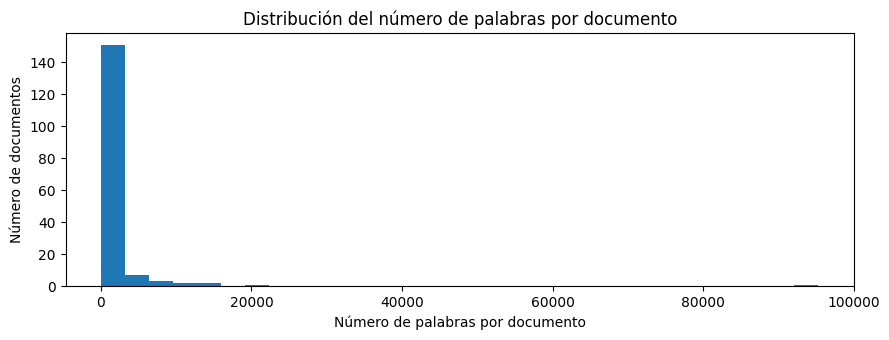

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_hist_text_length_words.png


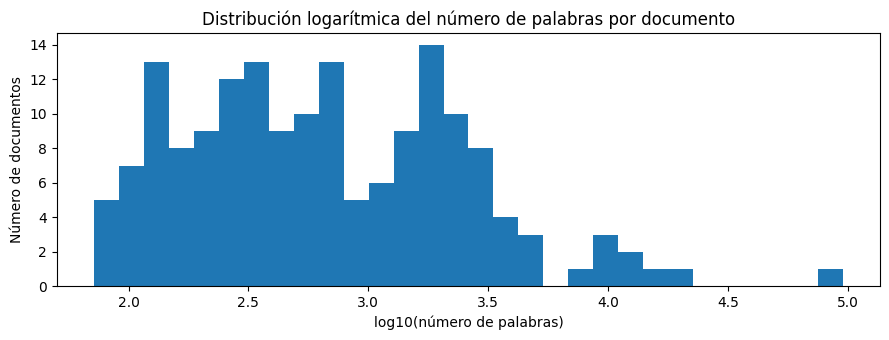

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_hist_log_text_length_words.png


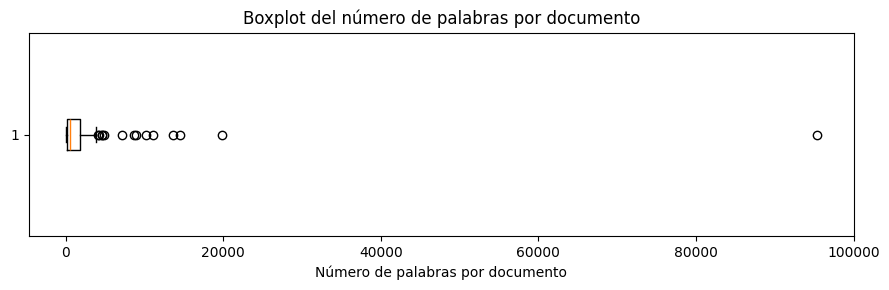

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_boxplot_text_length_words.png


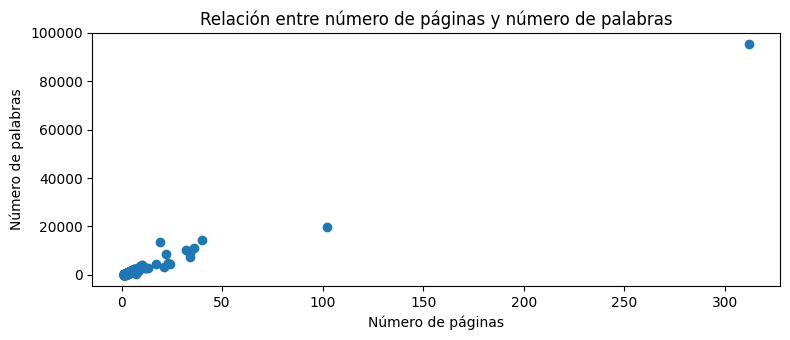

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_scatter_pages_words.png


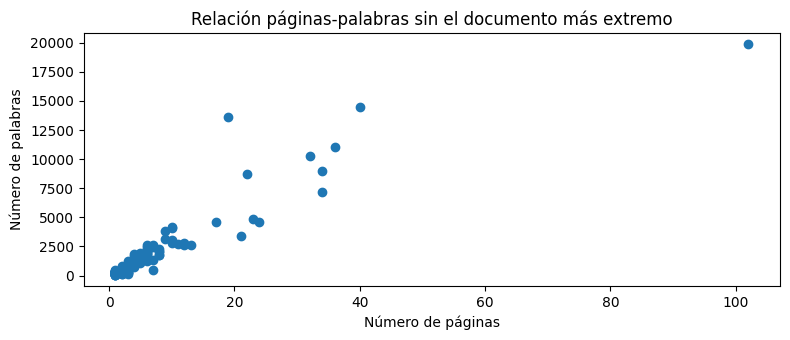

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_scatter_pages_words_without_extreme.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

print("=== VISUALIZACIÓN DE LONGITUDES DOCUMENTALES ===")

# Crear carpeta de figuras
figures_dir = ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# 1. Histograma de palabras por documento
plt.figure(figsize=(9, 3.5))
plt.hist(df_eda["text_length_words"].dropna(), bins=30)
plt.xlabel("Número de palabras por documento")
plt.ylabel("Número de documentos")
plt.title("Distribución del número de palabras por documento")
plt.tight_layout()

fig_path_1 = figures_dir / "eda_hist_text_length_words.png"
plt.savefig(fig_path_1, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_1)

# 2. Histograma en escala logarítmica
plt.figure(figsize=(9, 3.5))
plt.hist(np.log10(df_eda["text_length_words"].dropna()), bins=30)
plt.xlabel("log10(número de palabras)")
plt.ylabel("Número de documentos")
plt.title("Distribución logarítmica del número de palabras por documento")
plt.tight_layout()

fig_path_2 = figures_dir / "eda_hist_log_text_length_words.png"
plt.savefig(fig_path_2, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_2)

# 3. Boxplot del número de palabras
plt.figure(figsize=(9, 3))
plt.boxplot(df_eda["text_length_words"].dropna(), vert=False)
plt.xlabel("Número de palabras por documento")
plt.title("Boxplot del número de palabras por documento")
plt.tight_layout()

fig_path_3 = figures_dir / "eda_boxplot_text_length_words.png"
plt.savefig(fig_path_3, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_3)

# 4. Relación entre páginas y palabras
plt.figure(figsize=(8, 3.5))
plt.scatter(df_eda["pages"], df_eda["text_length_words"])
plt.xlabel("Número de páginas")
plt.ylabel("Número de palabras")
plt.title("Relación entre número de páginas y número de palabras")
plt.tight_layout()

fig_path_4 = figures_dir / "eda_scatter_pages_words.png"
plt.savefig(fig_path_4, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_4)

# 5. Relación entre páginas y palabras excluyendo el documento más extremo
df_without_extreme = df_eda[df_eda["text_length_words"] < df_eda["text_length_words"].max()].copy()

plt.figure(figsize=(8, 3.5))
plt.scatter(df_without_extreme["pages"], df_without_extreme["text_length_words"])
plt.xlabel("Número de páginas")
plt.ylabel("Número de palabras")
plt.title("Relación páginas-palabras sin el documento más extremo")
plt.tight_layout()

fig_path_5 = figures_dir / "eda_scatter_pages_words_without_extreme.png"
plt.savefig(fig_path_5, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_5)

### Interpretación de las visualizaciones de longitud

Las visualizaciones confirman que el corpus presenta una distribución de longitudes claramente asimétrica. El histograma original muestra que la mayoría de documentos se concentran en longitudes relativamente bajas, mientras que unos pocos documentos muy extensos desplazan la escala hacia la derecha. Por este motivo, el histograma en escala logarítmica resulta más informativo, ya que permite observar mejor la distribución interna de los documentos cortos y medianos.

El boxplot refuerza esta conclusión al mostrar varios documentos atípicos por longitud. Estos valores extremos no se interpretan inicialmente como errores, sino como documentos reales de gran extensión, como transcripciones, recopilaciones de télex, informes amplios o documentación judicial. Por tanto, no se eliminarán en esta fase, sino que se marcarán como documentos de longitud atípica para tenerlos en cuenta en fases posteriores.

La relación entre número de páginas y número de palabras muestra una tendencia positiva: los documentos con más páginas suelen contener más palabras. Sin embargo, al excluir el documento más extremo, se observa con mayor claridad que existen diferencias relevantes en la densidad textual entre documentos. Algunos textos presentan muchas palabras por página, lo que puede deberse tanto a documentos especialmente densos como a particularidades del OCR o de la estructura original del documento.

Desde el punto de vista de Machine Learning, esta heterogeneidad obliga a tomar precauciones. En modelos basados en frecuencia, como TF-IDF, los documentos largos pueden tener mayor influencia si no se normalizan adecuadamente. En modelos basados en embeddings o búsqueda semántica, los documentos muy extensos pueden requerir segmentación en fragmentos para evitar perder información o generar representaciones demasiado generales. Por ello, este análisis justifica que las fases posteriores de limpieza y modelado contemplen explícitamente la longitud documental.

## 5. Diagnóstico básico de calidad del texto OCR

Una vez analizada la longitud documental, se revisa la calidad básica del texto extraído mediante OCR. Aunque todos los documentos tienen texto disponible, esto no garantiza que el contenido sea completamente limpio o adecuado para modelos de NLP.

En esta fase se calculan métricas simples de calidad textual, como la proporción de caracteres alfabéticos, números, mayúsculas, líneas vacías y caracteres potencialmente extraños. El objetivo no es corregir todavía el texto, sino identificar posibles problemas de extracción que puedan afectar a fases posteriores de limpieza, representación vectorial y modelado.

Este diagnóstico permite distinguir entre documentos con texto razonablemente limpio y documentos que podrían requerir una revisión o tratamiento especial antes de ser utilizados en tareas como clasificación, clustering, topic modeling o búsqueda semántica.

In [7]:
print("=== DIAGNÓSTICO BÁSICO DE CALIDAD OCR ===")

# Copia de trabajo
df_quality = df_eda.copy()

# Asegurar que el texto está en formato string
df_quality["text_full"] = df_quality["text_full"].fillna("").astype(str)

def calculate_text_quality(text):
    """
    Calcula métricas sencillas para evaluar la calidad básica de un texto OCR.
    No limpia el texto: solo mide características.
    """
    total_chars = len(text)
    
    if total_chars == 0:
        return pd.Series({
            "alpha_ratio": 0,
            "digit_ratio": 0,
            "space_ratio": 0,
            "uppercase_ratio": 0,
            "empty_line_ratio": 0,
            "avg_line_length": 0,
            "weird_char_ratio": 0
        })
    
    letters = sum(char.isalpha() for char in text)
    digits = sum(char.isdigit() for char in text)
    spaces = sum(char.isspace() for char in text)
    
    uppercase_letters = sum(char.isupper() for char in text if char.isalpha())
    
    lines = text.splitlines()
    n_lines = len(lines)
    empty_lines = sum(1 for line in lines if line.strip() == "")
    
    normal_chars = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZáéíóúÁÉÍÓÚñÑüÜ0123456789 .,;:()[]{}¿?¡!-/\"'ºª%€#\n\r\t")
    weird_chars = sum(char not in normal_chars for char in text)
    
    return pd.Series({
        "alpha_ratio": letters / total_chars,
        "digit_ratio": digits / total_chars,
        "space_ratio": spaces / total_chars,
        "uppercase_ratio": uppercase_letters / letters if letters > 0 else 0,
        "empty_line_ratio": empty_lines / n_lines if n_lines > 0 else 0,
        "avg_line_length": total_chars / n_lines if n_lines > 0 else 0,
        "weird_char_ratio": weird_chars / total_chars
    })

# Aplicar función a todos los documentos
quality_metrics = df_quality["text_full"].apply(calculate_text_quality)

# Unir métricas al dataframe
df_quality = pd.concat([df_quality, quality_metrics], axis=1)

quality_columns = [
    "alpha_ratio",
    "digit_ratio",
    "space_ratio",
    "uppercase_ratio",
    "empty_line_ratio",
    "avg_line_length",
    "weird_char_ratio"
]

print("\nResumen de métricas de calidad OCR:")
display(df_quality[quality_columns].describe().T)

print("\nDocumentos con menor proporción de caracteres alfabéticos:")
display(
    df_quality[
        ["doc_id", "title", "pages", "text_length_words", "alpha_ratio", "digit_ratio", "weird_char_ratio", "pdf_url"]
    ]
    .sort_values("alpha_ratio", ascending=True)
    .head(10)
)

print("\nDocumentos con mayor proporción de caracteres potencialmente extraños:")
display(
    df_quality[
        ["doc_id", "title", "pages", "text_length_words", "alpha_ratio", "weird_char_ratio", "pdf_url"]
    ]
    .sort_values("weird_char_ratio", ascending=False)
    .head(10)
)

print("\nDocumentos con mayor proporción de mayúsculas:")
display(
    df_quality[
        ["doc_id", "title", "pages", "text_length_words", "uppercase_ratio", "alpha_ratio", "pdf_url"]
    ]
    .sort_values("uppercase_ratio", ascending=False)
    .head(10)
)

print("\nDocumentos con mayor proporción de líneas vacías:")
display(
    df_quality[
        ["doc_id", "title", "pages", "text_length_words", "empty_line_ratio", "avg_line_length", "pdf_url"]
    ]
    .sort_values("empty_line_ratio", ascending=False)
    .head(10)
)

=== DIAGNÓSTICO BÁSICO DE CALIDAD OCR ===

Resumen de métricas de calidad OCR:


,count,mean,std,min,25%,50%,75%,max
alpha_ratio,167.0,0.774315,0.031945,0.605882,0.759619,0.782667,0.794975,0.827997
digit_ratio,167.0,0.015484,0.014202,0.000000,0.007094,0.011487,0.019401,0.105042
space_ratio,167.0,0.174170,0.013111,0.147315,0.167819,0.171985,0.177283,0.256536
uppercase_ratio,167.0,0.179610,0.220607,0.000358,0.067494,0.101784,0.182736,1.000000
empty_line_ratio,167.0,0.404416,0.079392,0.000000,0.356654,0.424779,0.470588,0.496933
avg_line_length,167.0,68.013248,34.785837,16.333333,42.767368,66.160000,83.867560,271.461538
weird_char_ratio,167.0,0.002775,0.008737,0.000000,0.000000,0.000000,0.000992,0.061101



Documentos con menor proporción de caracteres alfabéticos:


,doc_id,title,pages,text_length_words,alpha_ratio,digit_ratio,weird_char_ratio,pdf_url
150,rtve_1710,"""Interesando comparecencia del capitán de la G...",2,236,0.605882,0.105042,0.000000,https://www.rtve.es/contenidos/documentos/23f-...
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,0.633411,0.012681,0.061101,https://www.rtve.es/contenidos/documentos/23f-...
121,rtve_1739,SECRETO: copia de telex dando instrucciones so...,3,175,0.691095,0.089054,0.000000,https://www.rtve.es/contenidos/documentos/23f-...
136,rtve_1724,RESERVADO: oficio dando cuenta toma de declara...,1,193,0.697087,0.013592,0.023301,https://www.rtve.es/contenidos/documentos/23f-...
162,rtve_1698,Documento manuscrito de posible planificación ...,7,469,0.701251,0.025018,0.002943,https://www.rtve.es/contenidos/documentos/23f-...
81,rtve_1779,"""Nota de la Brigada de Información Interior: E...",2,223,0.705096,0.033417,0.015038,https://www.rtve.es/contenidos/documentos/23f-...
166,rtve_1694,Transcripción de conversación telefónica de (p...,4,1216,0.711835,0.000472,0.000000,https://www.rtve.es/contenidos/documentos/23f-...
123,rtve_1737,SECRETO: comunicando sanción a consejeros del ...,1,218,0.713229,0.013969,0.022186,https://www.rtve.es/contenidos/documentos/23f-...
141,rtve_1719,RESERVADO: Informe de Asesoría Jurídica Genera...,2,494,0.717204,0.029749,0.009319,https://www.rtve.es/contenidos/documentos/23f-...
142,rtve_1718,RESERVADO: Hoja de servicios del Cap. Sánchez ...,1,90,0.717544,0.050877,0.000000,https://www.rtve.es/contenidos/documentos/23f-...



Documentos con mayor proporción de caracteres potencialmente extraños:


,doc_id,title,pages,text_length_words,alpha_ratio,weird_char_ratio,pdf_url
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,0.633411,0.061101,https://www.rtve.es/contenidos/documentos/23f-...
71,rtve_1789,"""Nota """"Posible golpe de estado"""" (sin firma).""",4,995,0.747871,0.057207,https://www.rtve.es/contenidos/documentos/23f-...
72,rtve_1788,"""Nota """"Involucionismo político provocado por ...",3,582,0.754233,0.044993,https://www.rtve.es/contenidos/documentos/23f-...
99,rtve_1761,D.17._AGMAE_R40201_Exp._215,1,169,0.728106,0.035642,https://www.rtve.es/contenidos/documentos/23f-...
84,rtve_1776,D.31._AGA-83-09301_exp._5,6,1926,0.735238,0.028082,https://www.rtve.es/contenidos/documentos/23f-...
101,rtve_1759,D.15._AGMAE_R40201_Exp._215,2,367,0.769865,0.023882,https://www.rtve.es/contenidos/documentos/23f-...
136,rtve_1724,RESERVADO: oficio dando cuenta toma de declara...,1,193,0.697087,0.023301,https://www.rtve.es/contenidos/documentos/23f-...
123,rtve_1737,SECRETO: comunicando sanción a consejeros del ...,1,218,0.713229,0.022186,https://www.rtve.es/contenidos/documentos/23f-...
36,rtve_1824,Vista oral 2/81 del Consejo Supremo de Justici...,3,1279,0.737719,0.019535,https://www.rtve.es/contenidos/documentos/23f-...
81,rtve_1779,"""Nota de la Brigada de Información Interior: E...",2,223,0.705096,0.015038,https://www.rtve.es/contenidos/documentos/23f-...



Documentos con mayor proporción de mayúsculas:


,doc_id,title,pages,text_length_words,uppercase_ratio,alpha_ratio,pdf_url
102,rtve_1758,D.14._AGMAE_R39017_Exp._4,2,650,1.000000,0.801230,https://www.rtve.es/contenidos/documentos/23f-...
155,rtve_1705,Referencias en los medios de comunicación soci...,1,334,1.000000,0.801737,https://www.rtve.es/contenidos/documentos/23f-...
121,rtve_1739,SECRETO: copia de telex dando instrucciones so...,3,175,1.000000,0.691095,https://www.rtve.es/contenidos/documentos/23f-...
116,rtve_1744,D.2._AGMAE_R39017_Exp._4,1,354,1.000000,0.778527,https://www.rtve.es/contenidos/documentos/23f-...
52,rtve_1808,Reacciones ante la sentencia 23-F. Declaracion...,2,397,1.000000,0.782667,https://www.rtve.es/contenidos/documentos/23f-...
54,rtve_1806,Comentarios sobre la sentencia del 23-F. Cuart...,1,240,1.000000,0.761174,https://www.rtve.es/contenidos/documentos/23f-...
107,rtve_1753,D.10._AGMAE_R39017_Exp._4,1,196,0.909990,0.803018,https://www.rtve.es/contenidos/documentos/23f-...
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª...,102,19857,0.903683,0.766593,https://www.rtve.es/contenidos/documentos/23f-...
88,rtve_1772,D.27._AGA-83-09301_exp._5,1,120,0.838499,0.752147,https://www.rtve.es/contenidos/documentos/23f-...
105,rtve_1755,D.12._AGMAE_R39017_Exp._4,1,113,0.838078,0.786014,https://www.rtve.es/contenidos/documentos/23f-...



Documentos con mayor proporción de líneas vacías:


,doc_id,title,pages,text_length_words,empty_line_ratio,avg_line_length,pdf_url
39,rtve_1821,Vista oral 2/81 del Consejo Supremo de Justici...,7,2579,0.496933,96.773006,https://www.rtve.es/contenidos/documentos/23f-...
64,rtve_1796,Informe sobre la participación de miembros de ...,8,1753,0.496689,67.311258,https://www.rtve.es/contenidos/documentos/23f-...
14,rtve_1846,Vista oral 2/81 del Consejo Supremo de Justici...,6,2099,0.496124,96.387597,https://www.rtve.es/contenidos/documentos/23f-...
27,rtve_1833,Vista oral 2/81 del Consejo Supremo de Justici...,10,2775,0.495050,79.613861,https://www.rtve.es/contenidos/documentos/23f-...
32,rtve_1828,Vista oral 2/81 del Consejo Supremo de Justici...,7,2411,0.494444,79.300000,https://www.rtve.es/contenidos/documentos/23f-...
37,rtve_1823,Vista oral 2/81 del Consejo Supremo de Justici...,5,1670,0.494118,120.023529,https://www.rtve.es/contenidos/documentos/23f-...
9,rtve_1851,Vista oral 2/81 del Consejo Supremo de Justici...,5,1165,0.493827,86.086420,https://www.rtve.es/contenidos/documentos/23f-...
66,rtve_1794,Resumen de la actuación del Departamento de De...,2,542,0.490196,65.450980,https://www.rtve.es/contenidos/documentos/23f-...
12,rtve_1848,Vista oral 2/81 del Consejo Supremo de Justici...,2,676,0.488372,95.441860,https://www.rtve.es/contenidos/documentos/23f-...
19,rtve_1841,Vista oral 2/81 del Consejo Supremo de Justici...,5,1630,0.488372,73.542636,https://www.rtve.es/contenidos/documentos/23f-...


### Revisión de caracteres potencialmente extraños

La métrica `weird_char_ratio` identifica caracteres que no pertenecen a una lista básica de caracteres esperados en documentos en español. Sin embargo, esta métrica debe interpretarse con cautela, ya que algunos caracteres marcados como extraños pueden corresponder a idiomas distintos, símbolos administrativos, signos tipográficos o marcas propias de documentos escaneados.

Por ello, antes de considerar estos casos como errores de OCR, se revisan explícitamente los caracteres detectados en los documentos con mayor proporción de caracteres extraños.

In [8]:
print("=== INSPECCIÓN DE CARACTERES POTENCIALMENTE EXTRAÑOS ===")

# Misma lista de caracteres considerados normales en el diagnóstico anterior
normal_chars = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZáéíóúÁÉÍÓÚñÑüÜ0123456789 .,;:()[]{}¿?¡!-/\"'ºª%€#\n\r\t")

# Seleccionamos los 5 documentos con mayor weird_char_ratio
top_weird_docs = df_quality.sort_values("weird_char_ratio", ascending=False).head(5)

for _, row in top_weird_docs.iterrows():
    text = row["text_full"]
    
    weird_chars = sorted(set(char for char in text if char not in normal_chars))
    
    print("\n" + "="*80)
    print("doc_id:", row["doc_id"])
    print("title:", row["title"])
    print("weird_char_ratio:", row["weird_char_ratio"])
    print("Caracteres potencialmente extraños encontrados:")
    print(weird_chars)
    
    print("\nPrimeros 800 caracteres del texto:")
    print(text[:800])

=== INSPECCIÓN DE CARACTERES POTENCIALMENTE EXTRAÑOS ===

doc_id: rtve_1786
title: "Juicio del 23-F: acotaciones al desarrollo del juicio
weird_char_ratio: 0.061101060622184386
Caracteres potencialmente extraños encontrados:
['*', '_', '|', '°', '×', '—', '☑']

Primeros 800 caracteres del texto:
25.02.82

JUICIO 23.F

# I VALERACION GENERAL

Nuestra plataforma de observación tiene un horizonte limitado, ya que no asistimos personalmente a las sesiones del juicio, ni conocemos con exactitud el contenido y las incidencias de las actuaciones procesales; por otra parte, la información disponible a través de los medios de comunicación, no es completa ni en extensión ni en exhaustividad.

Hecha esta reserva nos aventuramos a afirmar que, habida cuenta de su intrínseca complejidad y de las dificultades previsibles antes de iniciarlo, el balance de la primera semana del juicio es positivo en su conjunto, tanto en su desarrollo interno como en su proyección pública —sin que haya dado lugar a in

### Interpretación del diagnóstico de calidad OCR

La inspección de los documentos con mayor proporción de caracteres potencialmente extraños muestra que la mayor parte de estos caracteres no corresponde necesariamente a errores graves de OCR. En varios casos se trata de símbolos de formato, guiones largos, barras de tabla, caracteres tipográficos o caracteres propios de otros idiomas, especialmente en documentos de Asuntos Exteriores.

Por tanto, la métrica `weird_char_ratio` debe interpretarse como una señal de revisión y no como un criterio automático de exclusión. Los documentos con valores elevados se mantendrán inicialmente en el corpus, pero podrán marcarse para un tratamiento especial en fases posteriores.

La revisión también muestra que algunos textos pueden contener errores puntuales relevantes para tareas concretas. Por ejemplo, ciertas fechas pueden estar mal reconocidas por el OCR o por el proceso de transcripción. Esto es especialmente importante para un posible análisis temporal, donde no conviene extraer fechas del texto bruto sin validación adicional.

En conjunto, el OCR proporcionado por RTVE parece suficientemente utilizable para realizar análisis de NLP, aunque será necesario aplicar una limpieza textual básica y mantener controles de calidad antes de entrenar modelos o extraer conclusiones históricas.

In [9]:
print("=== CREACIÓN DE INDICADORES DE REVISIÓN DE CALIDAD ===")

df_quality_flags = df_quality.copy()

# Umbrales sencillos basados en lo observado en el EDA
df_quality_flags["flag_low_alpha_ratio"] = df_quality_flags["alpha_ratio"] < 0.70
df_quality_flags["flag_high_weird_chars"] = df_quality_flags["weird_char_ratio"] > 0.02
df_quality_flags["flag_high_uppercase"] = df_quality_flags["uppercase_ratio"] > 0.80
df_quality_flags["flag_short_text"] = df_quality_flags["text_length_words"] < 150
df_quality_flags["flag_long_text_outlier"] = df_quality_flags["is_length_outlier_iqr"]

# Número total de avisos por documento
flag_columns = [
    "flag_low_alpha_ratio",
    "flag_high_weird_chars",
    "flag_high_uppercase",
    "flag_short_text",
    "flag_long_text_outlier"
]

df_quality_flags["n_quality_flags"] = df_quality_flags[flag_columns].sum(axis=1)

print("\nNúmero de documentos marcados por cada indicador:")
display(df_quality_flags[flag_columns].sum().to_frame("n_documentos"))

print("\nDocumentos con más indicadores de revisión:")
display(
    df_quality_flags[
        [
            "doc_id",
            "title",
            "pages",
            "text_length_words",
            "alpha_ratio",
            "weird_char_ratio",
            "uppercase_ratio",
            "n_quality_flags"
        ] + flag_columns
    ]
    .sort_values(["n_quality_flags", "weird_char_ratio"], ascending=False)
    .head(20)
)

# Guardar tabla para trazabilidad
tables_dir = ROOT / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

quality_flags_path = tables_dir / "eda_quality_flags_rtve.csv"
df_quality_flags.to_csv(quality_flags_path, index=False)

print("\nTabla guardada en:")
print(quality_flags_path)

=== CREACIÓN DE INDICADORES DE REVISIÓN DE CALIDAD ===

Número de documentos marcados por cada indicador:


,n_documentos
flag_low_alpha_ratio,4
flag_high_weird_chars,8
flag_high_uppercase,11
flag_short_text,26
flag_long_text_outlier,14



Documentos con más indicadores de revisión:


,doc_id,title,pages,text_length_words,alpha_ratio,weird_char_ratio,uppercase_ratio,n_quality_flags,flag_low_alpha_ratio,flag_high_weird_chars,flag_high_uppercase,flag_short_text,flag_long_text_outlier
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,0.633411,0.061101,0.061238,3,True,True,False,False,True
136,rtve_1724,RESERVADO: oficio dando cuenta toma de declara...,1,193,0.697087,0.023301,0.164345,2,True,True,False,False,False
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª...,102,19857,0.766593,0.002594,0.903683,2,False,False,True,False,True
88,rtve_1772,D.27._AGA-83-09301_exp._5,1,120,0.752147,0.000000,0.838499,2,False,False,True,True,False
89,rtve_1771,D.26._AGA-83-09301_exp._5,1,149,0.770314,0.000000,0.834037,2,False,False,True,True,False
105,rtve_1755,D.12._AGMAE_R39017_Exp._4,1,113,0.786014,0.000000,0.838078,2,False,False,True,True,False
121,rtve_1739,SECRETO: copia de telex dando instrucciones so...,3,175,0.691095,0.000000,1.000000,2,True,False,True,False,False
71,rtve_1789,"""Nota """"Posible golpe de estado"""" (sin firma).""",4,995,0.747871,0.057207,0.022131,1,False,True,False,False,False
72,rtve_1788,"""Nota """"Involucionismo político provocado por ...",3,582,0.754233,0.044993,0.074086,1,False,True,False,False,False
99,rtve_1761,D.17._AGMAE_R40201_Exp._215,1,169,0.728106,0.035642,0.125874,1,False,True,False,False,False



Tabla guardada en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_quality_flags_rtve.csv


### Interpretación de los indicadores de revisión de calidad

A partir de las métricas anteriores se han creado indicadores binarios de revisión para identificar documentos que podrían requerir atención en fases posteriores de limpieza o modelado. Estos indicadores no implican la eliminación automática de documentos, sino que funcionan como señales de control de calidad.

Los resultados muestran que 4 documentos presentan una proporción baja de caracteres alfabéticos, 8 documentos contienen una proporción relativamente elevada de caracteres potencialmente extraños, 11 documentos presentan una proporción muy alta de mayúsculas, 26 documentos son especialmente cortos y 14 documentos son atípicamente largos según la regla IQR aplicada al número de palabras.

El caso con mayor número de indicadores es `rtve_1786`, correspondiente al documento “Juicio del 23-F: acotaciones al desarrollo del juicio”. Este documento combina longitud elevada, baja proporción relativa de caracteres alfabéticos y una proporción superior de caracteres especiales. Sin embargo, la inspección previa del texto indica que parte de estos caracteres corresponden a símbolos de formato o signos tipográficos, por lo que no se considera un error automático de extracción.

En conjunto, los indicadores permiten concluir que el texto OCR de RTVE es suficientemente utilizable para análisis exploratorio y técnicas de NLP, pero no debe utilizarse sin una limpieza previa. En fases posteriores será necesario normalizar ciertos caracteres, tratar saltos de línea, revisar documentos muy cortos o muy largos y considerar estrategias específicas para que los documentos extremos no distorsionen modelos basados en frecuencias, embeddings o clustering.

La tabla `eda_quality_flags_rtve.csv` se guarda como salida trazable del EDA para documentar qué documentos presentan señales de revisión y facilitar decisiones posteriores de preprocesamiento.

## 6. Enriquecimiento institucional del corpus mediante La Moncloa

El corpus principal del proyecto se construye a partir de RTVE, ya que esta fuente proporciona los 167 documentos, sus metadatos y el texto OCR completo. Sin embargo, La Moncloa aporta una estructura institucional más clara, al clasificar los documentos por secciones y subsecciones como Interior, Defensa, Guardia Civil, CNI o Exteriores.

En este bloque se utiliza la tabla de comparación entre RTVE y La Moncloa para enriquecer el corpus principal con información institucional. El objetivo no es sustituir RTVE como fuente principal, sino añadir variables de contexto que permitan analizar el corpus de forma más interpretable.

Esta fase también permite comprobar qué documentos de RTVE tienen correspondencia con La Moncloa y cuáles aparecen únicamente en RTVE. Esta diferencia será importante para justificar la cobertura documental del corpus y para decidir qué variables pueden utilizarse de forma fiable en análisis posteriores.

In [10]:
print("=== ENRIQUECIMIENTO INSTITUCIONAL RTVE - LA MONCLOA ===")

# Cargar tabla de documentos RTVE no emparejados con La Moncloa
not_matched_path = DATA_INTERIM / "rtve_not_matched_by_moncloa.csv"
df_rtve_only = pd.read_csv(not_matched_path)

print("\nTabla rtve_not_matched_by_moncloa:")
print(df_rtve_only.shape)
print(list(df_rtve_only.columns))

# Seleccionar columnas útiles de la comparación RTVE-Moncloa
comparison_cols = [
    "matched_rtve_doc_id",
    "moncloa_id",
    "moncloa_section",
    "moncloa_subsection",
    "moncloa_date",
    "match_score",
    "final_match_status",
    "manual_review"
]

df_comparison_reduced = df_comparison[comparison_cols].copy()

# Renombrar la clave para poder unirla con df_corpus
df_comparison_reduced = df_comparison_reduced.rename(
    columns={"matched_rtve_doc_id": "doc_id"}
)

# Unir el corpus principal de RTVE con la información institucional de La Moncloa
df_corpus_enriched = df_corpus.merge(
    df_comparison_reduced,
    on="doc_id",
    how="left",
    validate="one_to_one"
)

# Marcar documentos según cobertura
df_corpus_enriched["coverage_type"] = df_corpus_enriched["moncloa_id"].apply(
    lambda x: "matched_moncloa" if pd.notna(x) else "rtve_only"
)

# Para los documentos solo RTVE, dejamos sección como "rtve_only_no_moncloa_match"
df_corpus_enriched["institutional_section"] = df_corpus_enriched["moncloa_section"].fillna(
    "rtve_only_no_moncloa_match"
)

df_corpus_enriched["institutional_subsection"] = df_corpus_enriched["moncloa_subsection"].fillna(
    "rtve_only_no_moncloa_match"
)

print("\nDimensiones del corpus enriquecido:")
print(df_corpus_enriched.shape)

print("\nCobertura RTVE - La Moncloa:")
display(df_corpus_enriched["coverage_type"].value_counts().to_frame("n_documentos"))

print("\nDocumentos por sección institucional:")
display(df_corpus_enriched["institutional_section"].value_counts().to_frame("n_documentos"))

print("\nDocumentos por subsección institucional:")
display(df_corpus_enriched["institutional_subsection"].value_counts().to_frame("n_documentos"))

print("\nEstado final del matching:")
display(df_corpus_enriched["final_match_status"].value_counts(dropna=False).to_frame("n_documentos"))

print("\nDocumentos con revisión manual en el matching:")
display(df_corpus_enriched["manual_review"].value_counts(dropna=False).to_frame("n_documentos"))

print("\nDocumentos presentes en RTVE sin equivalente detectado en La Moncloa:")
display(
    df_corpus_enriched[df_corpus_enriched["coverage_type"] == "rtve_only"][
        ["doc_id", "title", "pages", "text_length_words", "summary", "pdf_url"]
    ]
)

# Guardar corpus enriquecido para siguientes fases
tables_dir = ROOT / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

enriched_path = tables_dir / "eda_corpus_enriched_rtve.csv"
df_corpus_enriched.to_csv(enriched_path, index=False)

print("\nCorpus enriquecido guardado en:")
print(enriched_path)

=== ENRIQUECIMIENTO INSTITUCIONAL RTVE - LA MONCLOA ===

Tabla rtve_not_matched_by_moncloa:
(12, 11)
['doc_id', 'source', 'source_document_id', 'title', 'pages', 'summary', 'keywords', 'detail_url', 'pdf_url', 'coverage_status', 'notes']

Dimensiones del corpus enriquecido:
(167, 24)

Cobertura RTVE - La Moncloa:


,n_documentos
coverage_type,
matched_moncloa,155
rtve_only,12



Documentos por sección institucional:


,n_documentos
institutional_section,
defensa,108
interior,28
exteriores,19
rtve_only_no_moncloa_match,12



Documentos por subsección institucional:


...


Documentos con revisión manual en el matching:


,n_documentos
manual_review,
False,150
NaN,12
True,5



Documentos presentes en RTVE sin equivalente detectado en La Moncloa:


,doc_id,title,pages,text_length_words,summary,pdf_url
99,rtve_1761,D.17._AGMAE_R40201_Exp._215,1,169,La página 1 presenta una comunicación oficial ...,https://www.rtve.es/contenidos/documentos/23f-...
100,rtve_1760,D.16._AGMAE_R40201_Exp._215,1,182,La página 1 contiene una moción aprobada unáni...,https://www.rtve.es/contenidos/documentos/23f-...
103,rtve_1757,D.13._AGMAE_R39017_Exp._4,1,78,"La carta, fechada el 16 de marzo de 1981 en Ma...",https://www.rtve.es/contenidos/documentos/23f-...
105,rtve_1755,D.12._AGMAE_R39017_Exp._4,1,113,El documento fechado en Washington el 10 de ma...,https://www.rtve.es/contenidos/documentos/23f-...
106,rtve_1754,D.11._AGMAE_R39017_Exp._4,1,114,El documento corresponde a la respuesta del Re...,https://www.rtve.es/contenidos/documentos/23f-...
107,rtve_1753,D.10._AGMAE_R39017_Exp._4,1,196,El comunicado urgente del Ministerio de Asunto...,https://www.rtve.es/contenidos/documentos/23f-...
108,rtve_1752,D.9._AGMAE_R39017_Exp._4,1,87,"La carta, fechada el 4 de marzo de 1931 en Mad...",https://www.rtve.es/contenidos/documentos/23f-...
110,rtve_1750,D.7._AGMAE_R39017_Exp._4,1,146,La carta de Ronald Reagan al primer ministro e...,https://www.rtve.es/contenidos/documentos/23f-...
111,rtve_1749,D.6._AGMAE_R39017_Exp. 4,1,134,La página 1 presenta una carta fechada el 27 d...,https://www.rtve.es/contenidos/documentos/23f-...
112,rtve_1748,D.5._AGMAE_R39017_Exp._4,1,184,La página 1 presenta una carta fechada el 27 d...,https://www.rtve.es/contenidos/documentos/23f-...



Corpus enriquecido guardado en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_corpus_enriched_rtve.csv


### Revisión de subsecciones institucionales incompletas

La unión entre RTVE y La Moncloa permite asignar una sección institucional a la mayoría de documentos del corpus. Sin embargo, el campo de subsección no siempre está informado en el inventario de La Moncloa. Por este motivo, antes de utilizar la subsección como variable de análisis, se revisan los documentos con subsección vacía para distinguir entre documentos realmente exclusivos de RTVE y documentos emparejados con La Moncloa pero sin subsección específica registrada.

In [11]:
print("=== DIAGNÓSTICO DE SUBSECCIONES INSTITUCIONALES ===")

# Documentos con match con La Moncloa pero sin subsección informada
df_missing_subsection = df_corpus_enriched[
    (df_corpus_enriched["coverage_type"] == "matched_moncloa") &
    (df_corpus_enriched["moncloa_subsection"].isna())
].copy()

print("\nDocumentos con match en La Moncloa pero sin moncloa_subsection:")
print(df_missing_subsection.shape)

print("\nDistribución por sección principal:")
display(
    df_missing_subsection["moncloa_section"]
    .value_counts(dropna=False)
    .to_frame("n_documentos")
)

print("\nListado de documentos con sección pero sin subsección:")
display(
    df_missing_subsection[
        [
            "doc_id",
            "title",
            "moncloa_id",
            "moncloa_section",
            "moncloa_subsection",
            "pages",
            "text_length_words",
            "final_match_status",
            "manual_review"
        ]
    ]
    .sort_values(["moncloa_section", "title"])
)

print("\nDocumentos RTVE-only reales:")
display(
    df_corpus_enriched[df_corpus_enriched["coverage_type"] == "rtve_only"][
        [
            "doc_id",
            "title",
            "pages",
            "text_length_words",
            "summary",
            "pdf_url"
        ]
    ]
)

=== DIAGNÓSTICO DE SUBSECCIONES INSTITUCIONALES ===

Documentos con match en La Moncloa pero sin moncloa_subsection:
(43, 24)

Distribución por sección principal:


,n_documentos
moncloa_section,
defensa,24
exteriores,19



Listado de documentos con sección pero sin subsección:


,doc_id,title,moncloa_id,moncloa_section,moncloa_subsection,pages,text_length_words,final_match_status,manual_review
142,rtve_1718,RESERVADO: Hoja de servicios del Cap. Sánchez ...,moncloa_0115,defensa,NaN,1,90,high_confidence_match,False
141,rtve_1719,RESERVADO: Informe de Asesoría Jurídica Genera...,moncloa_0116,defensa,NaN,2,494,high_confidence_match,False
135,rtve_1725,RESERVADO: comunicación del procesamiento de M...,moncloa_0121,defensa,NaN,1,347,high_confidence_match,False
129,rtve_1731,RESERVADO: comunicación procesamiento implicado.,moncloa_0122,defensa,NaN,1,136,high_confidence_match,False
130,rtve_1730,RESERVADO: comunicación procesamiento implicado.,moncloa_0123,defensa,NaN,1,147,high_confidence_match,False
131,rtve_1729,RESERVADO: comunicación procesamiento implicado.,moncloa_0127,defensa,NaN,1,140,high_confidence_match,False
132,rtve_1728,RESERVADO: comunicación procesamiento implicado.,moncloa_0124,defensa,NaN,1,133,high_confidence_match,False
133,rtve_1727,RESERVADO: comunicación procesamiento implicado.,moncloa_0126,defensa,NaN,1,140,high_confidence_match,False
134,rtve_1726,RESERVADO: comunicación procesamiento implicado.,moncloa_0125,defensa,NaN,1,154,high_confidence_match,False
120,rtve_1740,RESERVADO: dación en cuenta de recurso de quej...,moncloa_0135,defensa,NaN,1,266,high_confidence_match,False



Documentos RTVE-only reales:


,doc_id,title,pages,text_length_words,summary,pdf_url
99,rtve_1761,D.17._AGMAE_R40201_Exp._215,1,169,La página 1 presenta una comunicación oficial ...,https://www.rtve.es/contenidos/documentos/23f-...
100,rtve_1760,D.16._AGMAE_R40201_Exp._215,1,182,La página 1 contiene una moción aprobada unáni...,https://www.rtve.es/contenidos/documentos/23f-...
103,rtve_1757,D.13._AGMAE_R39017_Exp._4,1,78,"La carta, fechada el 16 de marzo de 1981 en Ma...",https://www.rtve.es/contenidos/documentos/23f-...
105,rtve_1755,D.12._AGMAE_R39017_Exp._4,1,113,El documento fechado en Washington el 10 de ma...,https://www.rtve.es/contenidos/documentos/23f-...
106,rtve_1754,D.11._AGMAE_R39017_Exp._4,1,114,El documento corresponde a la respuesta del Re...,https://www.rtve.es/contenidos/documentos/23f-...
107,rtve_1753,D.10._AGMAE_R39017_Exp._4,1,196,El comunicado urgente del Ministerio de Asunto...,https://www.rtve.es/contenidos/documentos/23f-...
108,rtve_1752,D.9._AGMAE_R39017_Exp._4,1,87,"La carta, fechada el 4 de marzo de 1931 en Mad...",https://www.rtve.es/contenidos/documentos/23f-...
110,rtve_1750,D.7._AGMAE_R39017_Exp._4,1,146,La carta de Ronald Reagan al primer ministro e...,https://www.rtve.es/contenidos/documentos/23f-...
111,rtve_1749,D.6._AGMAE_R39017_Exp. 4,1,134,La página 1 presenta una carta fechada el 27 d...,https://www.rtve.es/contenidos/documentos/23f-...
112,rtve_1748,D.5._AGMAE_R39017_Exp._4,1,184,La página 1 presenta una carta fechada el 27 d...,https://www.rtve.es/contenidos/documentos/23f-...


### Creación de variables institucionales limpias

El diagnóstico anterior muestra que la sección principal de La Moncloa permite clasificar correctamente gran parte del corpus, pero la subsección no siempre está informada. En particular, existen documentos emparejados con La Moncloa que tienen sección `defensa` o `exteriores`, pero no tienen una subsección explícita.

Para evitar que estos documentos se mezclen incorrectamente con los documentos exclusivos de RTVE, se construyen variables institucionales limpias. Estas variables permiten mantener la lógica principal del corpus:

- `defensa`
- `interior`
- `exteriores`

Además, se crea una subsección limpia para distinguir documentos del CNI, Guardia Civil, Policía, Archivo General de Defensa, Exteriores y otros bloques identificables.

Los documentos RTVE-only se revisan a partir de su título. Cuando el título contiene patrones como `D.`, `AGMAE` o `AGA`, se asignan al bloque de Exteriores, ya que corresponden a expedientes diplomáticos o documentación del Ministerio de Asuntos Exteriores.

In [12]:
print("=== CREACIÓN DE VARIABLES INSTITUCIONALES LIMPIAS ===")

df_corpus_clean = df_corpus_enriched.copy()

def infer_clean_section(row):
    """
    Crea una sección institucional limpia.
    Si La Moncloa informa la sección, se usa esa sección.
    Si el documento es RTVE-only pero el título parece de Exteriores, se clasifica como exteriores.
    """
    if pd.notna(row["moncloa_section"]):
        return row["moncloa_section"]
    
    title = str(row["title"]).upper()
    
    if title.startswith("D.") or "AGMAE" in title or "AGA-" in title:
        return "exteriores"
    
    return "no_identificado"

def infer_clean_subsection(row):
    """
    Crea una subsección institucional limpia.
    Se usa la subsección de La Moncloa si existe.
    Si está vacía, se completa con reglas simples basadas en sección y título.
    """
    if pd.notna(row["moncloa_subsection"]) and str(row["moncloa_subsection"]).strip() != "":
        return row["moncloa_subsection"]
    
    clean_section = row["institutional_section_clean"]
    title = str(row["title"]).upper()
    
    if clean_section == "defensa":
        return "archivo_general_defensa"
    
    if clean_section == "exteriores":
        return "exteriores"
    
    if clean_section == "interior":
        return "interior_sin_subseccion"
    
    if title.startswith("D.") or "AGMAE" in title or "AGA-" in title:
        return "exteriores"
    
    return "no_identificado"

# Crear variables limpias
df_corpus_clean["institutional_section_clean"] = df_corpus_clean.apply(infer_clean_section, axis=1)
df_corpus_clean["institutional_subsection_clean"] = df_corpus_clean.apply(infer_clean_subsection, axis=1)

# Crear una variable combinada para análisis más fino
df_corpus_clean["institutional_group_clean"] = (
    df_corpus_clean["institutional_section_clean"] 
    + " / " 
    + df_corpus_clean["institutional_subsection_clean"]
)

print("\nDistribución por sección institucional limpia:")
display(
    df_corpus_clean["institutional_section_clean"]
    .value_counts()
    .to_frame("n_documentos")
)

print("\nDistribución por subsección institucional limpia:")
display(
    df_corpus_clean["institutional_subsection_clean"]
    .value_counts()
    .to_frame("n_documentos")
)

print("\nDistribución por grupo institucional limpio:")
display(
    df_corpus_clean["institutional_group_clean"]
    .value_counts()
    .to_frame("n_documentos")
)

print("\nDocumentos no identificados:")
display(
    df_corpus_clean[df_corpus_clean["institutional_section_clean"] == "no_identificado"][
        ["doc_id", "title", "coverage_type", "moncloa_section", "moncloa_subsection"]
    ]
)

print("\nComprobación de cobertura total:")
print("Total documentos:", len(df_corpus_clean))
print("Documentos con sección limpia no identificada:", (df_corpus_clean["institutional_section_clean"] == "no_identificado").sum())
print("Documentos con subsección limpia no identificada:", (df_corpus_clean["institutional_subsection_clean"] == "no_identificado").sum())

# Guardar versión limpia
tables_dir = ROOT / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

clean_path = tables_dir / "eda_corpus_institutional_clean_rtve.csv"
df_corpus_clean.to_csv(clean_path, index=False)

print("\nCorpus con variables institucionales limpias guardado en:")
print(clean_path)

=== CREACIÓN DE VARIABLES INSTITUCIONALES LIMPIAS ===

Distribución por sección institucional limpia:


,n_documentos
institutional_section_clean,
defensa,108
exteriores,31
interior,28



Distribución por subsección institucional limpia:


,n_documentos
institutional_subsection_clean,
cni,84
exteriores,31
archivo_general_defensa,24
guardia-civil,11
policia,10
archivo,7



Distribución por grupo institucional limpio:


,n_documentos
institutional_group_clean,
defensa / cni,84
exteriores / exteriores,31
defensa / archivo_general_defensa,24
interior / guardia-civil,11
interior / policia,10
interior / archivo,7



Documentos no identificados:


,doc_id,title,coverage_type,moncloa_section,moncloa_subsection



Comprobación de cobertura total:
Total documentos: 167
Documentos con sección limpia no identificada: 0
Documentos con subsección limpia no identificada: 0

Corpus con variables institucionales limpias guardado en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_corpus_institutional_clean_rtve.csv


### Trazabilidad de las etiquetas institucionales

Las variables institucionales limpias permiten clasificar los 167 documentos del corpus en tres grandes bloques: Defensa, Interior y Exteriores. Sin embargo, no todas las etiquetas tienen el mismo origen. La mayoría proceden del emparejamiento con La Moncloa, mientras que los documentos exclusivos de RTVE se clasifican mediante una regla basada en patrones del título, como `D.`, `AGMAE` o `AGA`.

Para evitar confundir etiquetas oficiales con etiquetas inferidas, se añade una variable de trazabilidad que indica el origen de cada clasificación institucional. Esta distinción será importante si en fases posteriores se utilizan estas variables como referencia para análisis supervisados.

In [13]:
print("=== TRAZABILIDAD DE ETIQUETAS INSTITUCIONALES ===")

df_corpus_clean["institutional_label_source"] = df_corpus_clean.apply(
    lambda row: "moncloa_match" if pd.notna(row["moncloa_id"]) else "inferred_from_rtve_title",
    axis=1
)

print("\nOrigen de las etiquetas institucionales:")
display(
    df_corpus_clean["institutional_label_source"]
    .value_counts()
    .to_frame("n_documentos")
)

print("\nCruce entre sección limpia y origen de etiqueta:")
display(
    pd.crosstab(
        df_corpus_clean["institutional_section_clean"],
        df_corpus_clean["institutional_label_source"]
    )
)

print("\nDocumentos con etiqueta institucional inferida desde RTVE:")
display(
    df_corpus_clean[df_corpus_clean["institutional_label_source"] == "inferred_from_rtve_title"][
        [
            "doc_id",
            "title",
            "institutional_section_clean",
            "institutional_subsection_clean",
            "coverage_type",
            "pdf_url"
        ]
    ]
)

# Guardar de nuevo con la trazabilidad añadida
clean_path = tables_dir / "eda_corpus_institutional_clean_rtve.csv"
df_corpus_clean.to_csv(clean_path, index=False)

print("\nCorpus actualizado con trazabilidad guardado en:")
print(clean_path)

=== TRAZABILIDAD DE ETIQUETAS INSTITUCIONALES ===

Origen de las etiquetas institucionales:


,n_documentos
institutional_label_source,
moncloa_match,155
inferred_from_rtve_title,12



Cruce entre sección limpia y origen de etiqueta:


institutional_label_source,inferred_from_rtve_title,moncloa_match
institutional_section_clean,,
defensa,0,108
exteriores,12,19
interior,0,28



Documentos con etiqueta institucional inferida desde RTVE:


,doc_id,title,institutional_section_clean,institutional_subsection_clean,coverage_type,pdf_url
99,rtve_1761,D.17._AGMAE_R40201_Exp._215,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
100,rtve_1760,D.16._AGMAE_R40201_Exp._215,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
103,rtve_1757,D.13._AGMAE_R39017_Exp._4,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
105,rtve_1755,D.12._AGMAE_R39017_Exp._4,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
106,rtve_1754,D.11._AGMAE_R39017_Exp._4,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
107,rtve_1753,D.10._AGMAE_R39017_Exp._4,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
108,rtve_1752,D.9._AGMAE_R39017_Exp._4,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
110,rtve_1750,D.7._AGMAE_R39017_Exp._4,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
111,rtve_1749,D.6._AGMAE_R39017_Exp. 4,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...
112,rtve_1748,D.5._AGMAE_R39017_Exp._4,exteriores,exteriores,rtve_only,https://www.rtve.es/contenidos/documentos/23f-...



Corpus actualizado con trazabilidad guardado en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_corpus_institutional_clean_rtve.csv


### Interpretación de la trazabilidad institucional

La trazabilidad de etiquetas confirma que la mayor parte de la clasificación institucional procede del emparejamiento con La Moncloa. En concreto, 155 documentos reciben su sección institucional a partir de una correspondencia directa con esta fuente oficial, mientras que 12 documentos exclusivos de RTVE se clasifican mediante una regla basada en patrones del título.

Los 12 documentos inferidos pertenecen al bloque de Exteriores, ya que presentan identificadores como `D.`, `AGMAE` o `AGA`, asociados a expedientes diplomáticos y documentación del Ministerio de Asuntos Exteriores. Esta inferencia permite completar la estructura global del corpus hasta alcanzar los 31 documentos de Exteriores identificados en la fuente RTVE.

La distinción entre etiquetas procedentes de La Moncloa y etiquetas inferidas desde RTVE queda registrada mediante la variable `institutional_label_source`. Esto aporta trazabilidad al dataset y evita presentar como etiqueta oficial lo que realmente es una inferencia controlada. En fases posteriores, esta variable será especialmente importante si se emplea la sección institucional como variable objetivo en modelos supervisados.

In [14]:
print("=== EDA POR SECCIÓN INSTITUCIONAL ===")

# Resumen por sección institucional
section_summary = (
    df_corpus_clean
    .groupby("institutional_section_clean")
    .agg(
        n_documents=("doc_id", "count"),
        total_pages=("pages", "sum"),
        mean_pages=("pages", "mean"),
        median_pages=("pages", "median"),
        total_words=("text_length_words", "sum"),
        mean_words=("text_length_words", "mean"),
        median_words=("text_length_words", "median"),
        max_words=("text_length_words", "max")
    )
    .sort_values("n_documents", ascending=False)
)

print("\nResumen por sección institucional:")
display(section_summary)

# Resumen por grupo institucional más detallado
group_summary = (
    df_corpus_clean
    .groupby("institutional_group_clean")
    .agg(
        n_documents=("doc_id", "count"),
        total_pages=("pages", "sum"),
        mean_pages=("pages", "mean"),
        median_pages=("pages", "median"),
        total_words=("text_length_words", "sum"),
        mean_words=("text_length_words", "mean"),
        median_words=("text_length_words", "median"),
        max_words=("text_length_words", "max")
    )
    .sort_values("n_documents", ascending=False)
)

print("\nResumen por grupo institucional:")
display(group_summary)

# Guardar tablas
tables_dir = ROOT / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

section_summary_path = tables_dir / "eda_section_summary_rtve.csv"
group_summary_path = tables_dir / "eda_group_summary_rtve.csv"

section_summary.to_csv(section_summary_path)
group_summary.to_csv(group_summary_path)

print("\nTablas guardadas:")
print(section_summary_path)
print(group_summary_path)

=== EDA POR SECCIÓN INSTITUCIONAL ===

Resumen por sección institucional:


,n_documents,total_pages,mean_pages,median_pages,total_words,mean_words,median_words,max_words
institutional_section_clean,,,,,,,,
defensa,108,489,4.527778,3.0,146129,1353.046296,728.0,14485
exteriores,31,52,1.677419,1.0,10204,329.161290,237.0,1926
interior,28,688,24.571429,6.0,190266,6795.214286,1162.0,95293



Resumen por grupo institucional:


,n_documents,total_pages,mean_pages,median_pages,total_words,mean_words,median_words,max_words
institutional_group_clean,,,,,,,,
defensa / cni,84,442,5.261905,4.0,136757,1628.059524,1222.0,14485
exteriores / exteriores,31,52,1.677419,1.0,10204,329.161290,237.0,1926
defensa / archivo_general_defensa,24,47,1.958333,1.0,9372,390.500000,184.0,2137
interior / guardia-civil,11,501,45.545455,7.0,137175,12470.454545,1216.0,95293
interior / policia,10,90,9.000000,2.0,16345,1634.500000,231.5,7189
interior / archivo,7,97,13.857143,10.0,36746,5249.428571,4105.0,13639



Tablas guardadas:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_section_summary_rtve.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_group_summary_rtve.csv


=== VISUALIZACIÓN POR SECCIÓN INSTITUCIONAL ===


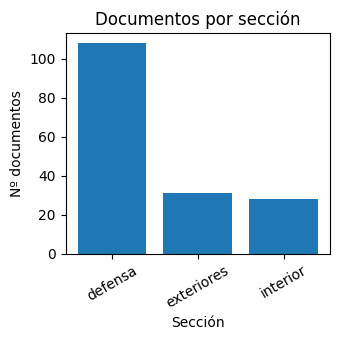

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_documents_by_section.png


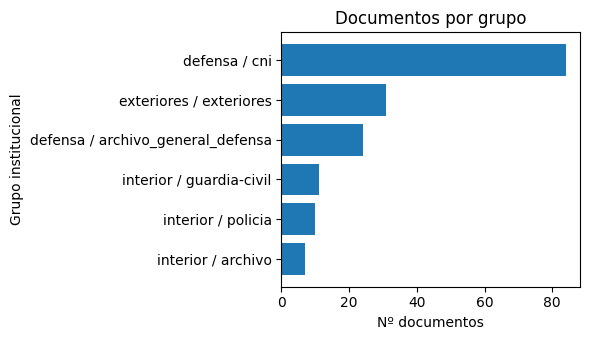

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_documents_by_institutional_group.png


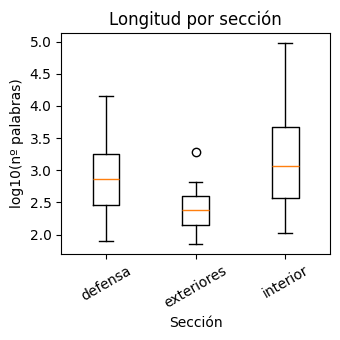

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_log_words_by_section_boxplot.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

print("=== VISUALIZACIÓN POR SECCIÓN INSTITUCIONAL ===")

figures_dir = ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# 1. Número de documentos por sección
section_counts = df_corpus_clean["institutional_section_clean"].value_counts()

plt.figure(figsize=(3.5, 3.5))
plt.bar(section_counts.index, section_counts.values)
plt.xlabel("Sección")
plt.ylabel("Nº documentos")
plt.title("Documentos por sección")
plt.xticks(rotation=30)
plt.tight_layout()

fig_path_1 = figures_dir / "eda_documents_by_section.png"
plt.savefig(fig_path_1, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_1)

# 2. Número de documentos por grupo institucional
group_counts = df_corpus_clean["institutional_group_clean"].value_counts()

plt.figure(figsize=(6, 3.5))
plt.barh(group_counts.index, group_counts.values)
plt.xlabel("Nº documentos")
plt.ylabel("Grupo institucional")
plt.title("Documentos por grupo")
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path_2 = figures_dir / "eda_documents_by_institutional_group.png"
plt.savefig(fig_path_2, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_2)

# 3. Boxplot de palabras por sección en escala logarítmica
sections = sorted(df_corpus_clean["institutional_section_clean"].unique())

data_by_section = [
    np.log10(
        df_corpus_clean.loc[
            df_corpus_clean["institutional_section_clean"] == section,
            "text_length_words"
        ]
    )
    for section in sections
]

plt.figure(figsize=(3.5, 3.5))
plt.boxplot(data_by_section, tick_labels=sections)
plt.xlabel("Sección")
plt.ylabel("log10(nº palabras)")
plt.title("Longitud por sección")
plt.xticks(rotation=30)
plt.tight_layout()

fig_path_3 = figures_dir / "eda_log_words_by_section_boxplot.png"
plt.savefig(fig_path_3, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_3)

### Interpretación del análisis institucional

El análisis por sección institucional muestra un corpus claramente desbalanceado. La sección de Defensa concentra la mayor parte de los documentos, con 108 registros, seguida de Exteriores con 31 e Interior con 28. Este desbalance será relevante si en fases posteriores se plantea una tarea de clasificación supervisada por sección institucional, ya que el modelo podría tender a favorecer la clase mayoritaria.

El análisis por grupo institucional permite observar con mayor detalle la composición del corpus. El bloque más representado es `defensa / cni`, con 84 documentos, seguido de `exteriores / exteriores`, con 31 documentos, y `defensa / archivo_general_defensa`, con 24 documentos. Los grupos de Interior se dividen entre Guardia Civil, Policía y Archivo, con tamaños menores.

Además del número de documentos, existen diferencias relevantes en la longitud textual. La sección de Interior presenta una longitud media elevada y una dispersión mayor, influida especialmente por documentos extensos como transcripciones o recopilaciones. Exteriores, en cambio, contiene documentos generalmente más breves. Defensa ocupa una posición intermedia, aunque con un volumen documental claramente superior.

Estas diferencias indican que las fases posteriores de preprocesamiento y modelado deberán tener en cuenta tanto el desbalance de clases como el desbalance de longitud. En particular, si se aplican modelos basados en frecuencias, embeddings o clasificación supervisada, será necesario controlar que los documentos más largos o las clases más representadas no dominen de forma artificial los resultados.

## 8. Análisis léxico preliminar del corpus

Una vez revisada la estructura documental, la calidad OCR y la distribución institucional del corpus, se realiza un primer análisis léxico sobre el texto completo de los documentos.

El objetivo de este bloque no es todavía construir variables finales para modelos, sino entender qué términos aparecen con mayor frecuencia en el corpus y si existen diferencias preliminares entre secciones institucionales. Para ello se aplica una tokenización básica: conversión a minúsculas, eliminación de signos de puntuación, eliminación de números y filtrado de palabras vacías frecuentes en español.

Este análisis permite obtener una primera visión del contenido textual del corpus, detectar términos dominantes y valorar qué limpieza adicional será necesaria antes de aplicar técnicas más avanzadas como TF-IDF, clustering, topic modeling, embeddings o clasificación supervisada.

Las frecuencias obtenidas en este bloque tienen carácter exploratorio. En fases posteriores de modelado, las transformaciones textuales deberán ajustarse únicamente sobre el conjunto de entrenamiento para evitar fugas de información.

In [16]:
import re
from collections import Counter

print("=== ANÁLISIS LÉXICO PRELIMINAR ===")

# Copia de trabajo
df_text_eda = df_corpus_clean.copy()

# Lista básica de stopwords en español.
# Es una lista manual y simple para EDA, no una limpieza definitiva.
spanish_stopwords = set([
    "de", "la", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para",
    "con", "no", "una", "su", "al", "lo", "como", "más", "pero", "sus", "le", "ya",
    "o", "este", "sí", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre",
    "también", "me", "hasta", "hay", "donde", "quien", "desde", "todo", "nos",
    "durante", "todos", "uno", "les", "ni", "contra", "otros", "ese", "eso",
    "ante", "ellos", "e", "esto", "mí", "antes", "algunos", "qué", "unos",
    "yo", "otro", "otras", "otra", "él", "tanto", "esa", "estos", "mucho",
    "quienes", "nada", "muchos", "cual", "poco", "ella", "estar", "estas",
    "algunas", "algo", "nosotros", "mi", "mis", "tú", "te", "ti", "tu",
    "tus", "ellas", "nosotras", "vosotros", "vosotras", "os", "mío", "mía",
    "míos", "mías", "tuyo", "tuya", "tuyos", "tuyas", "suyo", "suya",
    "suyos", "suyas", "nuestro", "nuestra", "nuestros", "nuestras", "vuestro",
    "vuestra", "vuestros", "vuestras", "esos", "esas", "estoy", "estás",
    "está", "estamos", "estáis", "están", "esté", "estés", "estemos",
    "estéis", "estén", "estaré", "estarás", "estará", "estaremos", "estarán",
    "ser", "soy", "eres", "es", "somos", "son", "era", "eran", "fue", "fueron",
    "ha", "han", "he", "hemos", "había", "habían", "fuerza"
])

def tokenize_basic(text):
    """
    Tokenización básica para EDA:
    - minúsculas
    - elimina URLs
    - elimina números y puntuación
    - conserva letras españolas
    - elimina stopwords
    - elimina tokens muy cortos
    """
    text = str(text).lower()
    
    # Eliminar URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Mantener solo letras españolas y espacios
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)
    
    # Separar en palabras
    tokens = text.split()
    
    # Filtrar stopwords y palabras muy cortas
    tokens = [
        token for token in tokens
        if token not in spanish_stopwords and len(token) >= 3
    ]
    
    return tokens

# Crear tokens por documento
df_text_eda["tokens_basic"] = df_text_eda["text_full"].apply(tokenize_basic)
df_text_eda["n_tokens_basic"] = df_text_eda["tokens_basic"].apply(len)

print("\nResumen de tokens tras limpieza básica:")
display(df_text_eda["n_tokens_basic"].describe().to_frame("n_tokens_basic"))

# Frecuencias globales
all_tokens = []

for tokens in df_text_eda["tokens_basic"]:
    all_tokens.extend(tokens)

global_counter = Counter(all_tokens)

df_global_terms = pd.DataFrame(
    global_counter.most_common(30),
    columns=["term", "frequency"]
)

print("\nTop 30 términos más frecuentes del corpus:")
display(df_global_terms)

# Frecuencias por sección institucional
section_rows = []

for section, group in df_text_eda.groupby("institutional_section_clean"):
    section_tokens = []
    
    for tokens in group["tokens_basic"]:
        section_tokens.extend(tokens)
    
    section_counter = Counter(section_tokens)
    
    for rank, (term, frequency) in enumerate(section_counter.most_common(20), start=1):
        section_rows.append({
            "section": section,
            "rank": rank,
            "term": term,
            "frequency": frequency
        })

df_terms_by_section = pd.DataFrame(section_rows)

print("\nTop 20 términos más frecuentes por sección institucional:")
display(df_terms_by_section)

# Guardar tablas
tables_dir = ROOT / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

global_terms_path = tables_dir / "eda_global_top_terms.csv"
section_terms_path = tables_dir / "eda_terms_by_section.csv"

df_global_terms.to_csv(global_terms_path, index=False)
df_terms_by_section.to_csv(section_terms_path, index=False)

print("\nTablas guardadas:")
print(global_terms_path)
print(section_terms_path)

=== ANÁLISIS LÉXICO PRELIMINAR ===

Resumen de tokens tras limpieza básica:


,n_tokens_basic
count,167.000000
mean,1015.724551
std,3252.262191
min,39.000000
25%,130.000000
50%,309.000000
75%,935.500000
max,38911.000000



Top 30 términos más frecuentes del corpus:


,term,frequency
0,que,11169
1,general,1891
2,coronel,873
3,civil,836
4,teniente,744
5,congreso,711
6,guardia,704
7,tejero,699
8,militar,657
9,capitán,603



Top 20 términos más frecuentes por sección institucional:


,section,rank,term,frequency
0,defensa,1,que,4421
1,defensa,2,general,1275
2,defensa,3,coronel,517
3,defensa,4,armada,508
4,defensa,5,teniente,502
5,defensa,6,capitán,502
6,defensa,7,congreso,450
7,defensa,8,tejero,387
8,defensa,9,civil,387
9,defensa,10,militar,345



Tablas guardadas:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_global_top_terms.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_terms_by_section.csv


### Revisión de la primera tokenización

La primera tokenización permite obtener una visión inicial del vocabulario del corpus, pero también muestra limitaciones claras de la lista básica de stopwords. En particular, aparecen términos funcionales muy frecuentes como `que`, así como palabras propias de transcripciones orales, como `bueno`, `pues`, `ver` o `ahora`.

Además, en la sección de Exteriores aparecen términos vacíos en inglés, como `the`, `and` o `that`, lo que indica que parte del corpus contiene documentación multilingüe. Por este motivo, se realiza una segunda tokenización exploratoria con una lista de stopwords ampliada, incluyendo términos funcionales en español, algunas palabras frecuentes de transcripción y stopwords básicas en inglés.

Esta limpieza sigue teniendo carácter exploratorio. No representa aún el preprocesamiento definitivo para modelos, pero permite obtener una lectura más informativa del contenido semántico del corpus.

In [17]:
print("=== ANÁLISIS LÉXICO CON STOPWORDS AMPLIADAS ===")

# Stopwords adicionales detectadas tras la primera revisión
extra_stopwords = set([
    "que", "qué", "bien", "bueno", "pues", "dicho", "ver", "ahora", "aquí",
    "ahi", "ahí", "voy", "va", "van", "ser", "sido", "hacer", "hace",
    "puede", "pueden", "debe", "deben", "según", "así", "solo", "sólo",
    "tal", "vez", "forma", "parte", "caso", "casos", "respecto",
    "documento", "documentos", "nota", "informe", "asunto"
])

# Stopwords básicas en inglés, útiles para documentos de Exteriores
english_stopwords_basic = set([
    "the", "and", "that", "this", "with", "from", "for", "are", "was", "were",
    "has", "have", "had", "not", "but", "you", "your", "his", "her", "their",
    "our", "its", "will", "would", "can", "could", "should", "may", "might",
    "been", "being", "into", "about", "after", "before", "between", "also",
    "than", "then", "there", "here", "when", "where", "who", "what", "which"
])

# Nueva lista combinada
refined_stopwords = spanish_stopwords | extra_stopwords | english_stopwords_basic

def tokenize_refined(text):
    """
    Tokenización exploratoria refinada:
    - minúsculas
    - elimina URLs
    - elimina números y puntuación
    - conserva letras españolas
    - elimina stopwords ampliadas
    - elimina tokens muy cortos
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)
    
    tokens = text.split()
    
    tokens = [
        token for token in tokens
        if token not in refined_stopwords and len(token) >= 3
    ]
    
    return tokens

# Aplicar tokenización refinada
df_text_eda["tokens_refined"] = df_text_eda["text_full"].apply(tokenize_refined)
df_text_eda["n_tokens_refined"] = df_text_eda["tokens_refined"].apply(len)

print("\nResumen de tokens tras stopwords ampliadas:")
display(df_text_eda["n_tokens_refined"].describe().to_frame("n_tokens_refined"))

# Frecuencias globales refinadas
all_tokens_refined = []

for tokens in df_text_eda["tokens_refined"]:
    all_tokens_refined.extend(tokens)

global_counter_refined = Counter(all_tokens_refined)

df_global_terms_refined = pd.DataFrame(
    global_counter_refined.most_common(30),
    columns=["term", "frequency"]
)

print("\nTop 30 términos globales tras stopwords ampliadas:")
display(df_global_terms_refined)

# Frecuencias refinadas por sección
section_rows_refined = []

for section, group in df_text_eda.groupby("institutional_section_clean"):
    section_tokens = []
    
    for tokens in group["tokens_refined"]:
        section_tokens.extend(tokens)
    
    section_counter = Counter(section_tokens)
    
    for rank, (term, frequency) in enumerate(section_counter.most_common(20), start=1):
        section_rows_refined.append({
            "section": section,
            "rank": rank,
            "term": term,
            "frequency": frequency
        })

df_terms_by_section_refined = pd.DataFrame(section_rows_refined)

print("\nTop 20 términos por sección tras stopwords ampliadas:")
display(df_terms_by_section_refined)

# Guardar resultados
global_terms_refined_path = tables_dir / "eda_global_top_terms_refined.csv"
section_terms_refined_path = tables_dir / "eda_terms_by_section_refined.csv"

df_global_terms_refined.to_csv(global_terms_refined_path, index=False)
df_terms_by_section_refined.to_csv(section_terms_refined_path, index=False)

print("\nTablas guardadas:")
print(global_terms_refined_path)
print(section_terms_refined_path)

=== ANÁLISIS LÉXICO CON STOPWORDS AMPLIADAS ===

Resumen de tokens tras stopwords ampliadas:


,n_tokens_refined
count,167.000000
mean,901.077844
std,2633.061185
min,38.000000
25%,117.000000
50%,288.000000
75%,860.500000
max,30499.000000



Top 30 términos globales tras stopwords ampliadas:


,term,frequency
0,general,1891
1,coronel,873
2,civil,836
3,teniente,744
4,congreso,711
5,guardia,704
6,tejero,699
7,militar,657
8,capitán,603
9,armada,586



Top 20 términos por sección tras stopwords ampliadas:


,section,rank,term,frequency
0,defensa,1,general,1275
1,defensa,2,coronel,517
2,defensa,3,armada,508
3,defensa,4,teniente,502
4,defensa,5,capitán,502
5,defensa,6,congreso,450
6,defensa,7,tejero,387
7,defensa,8,civil,387
8,defensa,9,militar,345
9,defensa,10,guardia,340



Tablas guardadas:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_global_top_terms_refined.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_terms_by_section_refined.csv


### Interpretación de la tokenización refinada

La segunda tokenización, basada en una lista ampliada de stopwords, permite obtener un vocabulario más informativo que la primera aproximación. Tras eliminar términos funcionales frecuentes en español, algunas palabras propias de transcripciones orales y stopwords básicas en inglés, emergen términos coherentes con el contenido histórico y documental del corpus.

A nivel global destacan términos relacionados con actores militares, instituciones y hechos centrales del 23-F, como `general`, `coronel`, `guardia`, `tejero`, `congreso`, `militar`, `armada`, `rey` o `gobierno`.

El análisis por sección muestra diferencias preliminares entre bloques institucionales. Defensa concentra vocabulario asociado al ámbito militar y judicial; Interior muestra términos relacionados con Guardia Civil, comunicaciones y referencias policiales; y Exteriores incorpora términos en inglés y referencias diplomáticas, como `spain`, `spanish`, `democracy`, `embajador` o `haig`.

No obstante, estas frecuencias son absolutas. Dado que las secciones tienen tamaños documentales y volúmenes de texto distintos, es necesario calcular frecuencias relativas para comparar el peso de los términos entre secciones de forma más equilibrada.

## 9. Frecuencias relativas por sección institucional

Para comparar el vocabulario entre secciones institucionales, no basta con observar frecuencias absolutas. Una sección con más documentos o más palabras tenderá a acumular más apariciones de cualquier término.

Por ello, en este bloque se calculan frecuencias relativas por cada 10.000 tokens. Esta normalización permite comparar mejor qué términos son proporcionalmente más frecuentes en Defensa, Interior o Exteriores, independientemente del tamaño total de cada bloque.

In [18]:
print("=== FRECUENCIAS RELATIVAS POR SECCIÓN ===")

relative_rows = []

for section, group in df_text_eda.groupby("institutional_section_clean"):
    section_tokens = []
    
    for tokens in group["tokens_refined"]:
        section_tokens.extend(tokens)
    
    total_tokens = len(section_tokens)
    section_counter = Counter(section_tokens)
    
    for term, frequency in section_counter.most_common(30):
        relative_rows.append({
            "section": section,
            "term": term,
            "absolute_frequency": frequency,
            "total_section_tokens": total_tokens,
            "frequency_per_10000_tokens": frequency / total_tokens * 10000
        })

df_relative_terms_by_section = pd.DataFrame(relative_rows)

print("\nTop 15 términos por sección, normalizados por cada 10.000 tokens:")
display(
    df_relative_terms_by_section
    .groupby("section")
    .head(15)
    .reset_index(drop=True)
)

# Guardar tabla
relative_terms_path = tables_dir / "eda_terms_by_section_relative.csv"
df_relative_terms_by_section.to_csv(relative_terms_path, index=False)

print("\nTabla guardada:")
print(relative_terms_path)

=== FRECUENCIAS RELATIVAS POR SECCIÓN ===

Top 15 términos por sección, normalizados por cada 10.000 tokens:


,section,term,absolute_frequency,total_section_tokens,frequency_per_10000_tokens
0,defensa,general,1275,70151,181.750795
1,defensa,coronel,517,70151,73.698165
2,defensa,armada,508,70151,72.415219
3,defensa,teniente,502,70151,71.559921
4,defensa,capitán,502,70151,71.559921
5,defensa,congreso,450,70151,64.147339
6,defensa,tejero,387,70151,55.166712
7,defensa,civil,387,70151,55.166712
8,defensa,militar,345,70151,49.179627
9,defensa,guardia,340,70151,48.466879



Tabla guardada:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_terms_by_section_relative.csv


### Interpretación de las frecuencias relativas por sección

El cálculo de frecuencias relativas por cada 10.000 tokens permite comparar el vocabulario de las secciones institucionales de forma más equilibrada, corrigiendo parcialmente las diferencias de tamaño entre bloques documentales.

Los resultados muestran perfiles léxicos coherentes con la naturaleza de cada sección. En Defensa destacan términos vinculados al ámbito militar y judicial, como `general`, `coronel`, `armada`, `teniente`, `capitán`, `defensor` o `fiscal`. En Interior aparecen términos relacionados con Guardia Civil, comunicaciones, declaraciones y referencias policiales, como `civil`, `guardia`, `tejero`, `hablar`, `efe` o `xerocopia`. En Exteriores destacan términos asociados al ámbito diplomático e internacional, incluyendo vocabulario en inglés como `spain`, `spanish` o `democracy`, además de referencias como `embajador`, `ministro`, `juan`, `carlos` o `haig`.

Este análisis confirma que las secciones institucionales presentan diferencias temáticas observables ya desde un análisis léxico simple. No obstante, las frecuencias relativas deben interpretarse con cautela, especialmente en Exteriores, ya que esta sección contiene un volumen textual mucho menor que Defensa e Interior. Por tanto, una misma frecuencia absoluta puede generar un peso relativo mayor.

Las diferencias detectadas justifican avanzar hacia análisis textuales algo más ricos, como bigramas y trigramas, ya que muchas expresiones relevantes del corpus no aparecen como palabras aisladas, sino como combinaciones de términos: `guardia civil`, `teniente coronel`, `consejo supremo`, `golpe estado` o `asuntos exteriores`.

## 10. Análisis de bigramas y trigramas

El análisis de palabras individuales permite obtener una primera visión del vocabulario del corpus, pero muchas expresiones relevantes aparecen como combinaciones de dos o tres términos. Por este motivo se analizan bigramas y trigramas construidos a partir de la tokenización refinada.

Este análisis permite detectar expresiones recurrentes del corpus, como nombres de instituciones, cargos militares, procedimientos judiciales o conceptos históricos. Al igual que en los análisis anteriores, esta fase tiene carácter exploratorio y no representa todavía la extracción final de características para modelos.

In [19]:
print("=== ANÁLISIS DE BIGRAMAS Y TRIGRAMAS ===")

def get_ngrams(tokens, n):
    """
    Construye n-gramas a partir de una lista de tokens.
    Ejemplo:
    tokens = ["guardia", "civil", "congreso"]
    bigramas = ["guardia civil", "civil congreso"]
    """
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

# Crear bigramas y trigramas por documento
df_text_eda["bigrams"] = df_text_eda["tokens_refined"].apply(lambda tokens: get_ngrams(tokens, 2))
df_text_eda["trigrams"] = df_text_eda["tokens_refined"].apply(lambda tokens: get_ngrams(tokens, 3))

# Bigramas globales
all_bigrams = []
for bigrams in df_text_eda["bigrams"]:
    all_bigrams.extend(bigrams)

bigram_counter = Counter(all_bigrams)

df_top_bigrams = pd.DataFrame(
    bigram_counter.most_common(30),
    columns=["bigram", "frequency"]
)

print("\nTop 30 bigramas globales:")
display(df_top_bigrams)

# Trigramas globales
all_trigrams = []
for trigrams in df_text_eda["trigrams"]:
    all_trigrams.extend(trigrams)

trigram_counter = Counter(all_trigrams)

df_top_trigrams = pd.DataFrame(
    trigram_counter.most_common(30),
    columns=["trigram", "frequency"]
)

print("\nTop 30 trigramas globales:")
display(df_top_trigrams)

# Bigramas por sección
bigram_section_rows = []

for section, group in df_text_eda.groupby("institutional_section_clean"):
    section_bigrams = []
    
    for bigrams in group["bigrams"]:
        section_bigrams.extend(bigrams)
    
    counter = Counter(section_bigrams)
    
    for rank, (bigram, frequency) in enumerate(counter.most_common(15), start=1):
        bigram_section_rows.append({
            "section": section,
            "rank": rank,
            "bigram": bigram,
            "frequency": frequency
        })

df_bigrams_by_section = pd.DataFrame(bigram_section_rows)

print("\nTop 15 bigramas por sección:")
display(df_bigrams_by_section)

# Trigramas por sección
trigram_section_rows = []

for section, group in df_text_eda.groupby("institutional_section_clean"):
    section_trigrams = []
    
    for trigrams in group["trigrams"]:
        section_trigrams.extend(trigrams)
    
    counter = Counter(section_trigrams)
    
    for rank, (trigram, frequency) in enumerate(counter.most_common(15), start=1):
        trigram_section_rows.append({
            "section": section,
            "rank": rank,
            "trigram": trigram,
            "frequency": frequency
        })

df_trigrams_by_section = pd.DataFrame(trigram_section_rows)

print("\nTop 15 trigramas por sección:")
display(df_trigrams_by_section)

# Guardar resultados
top_bigrams_path = tables_dir / "eda_top_bigrams.csv"
top_trigrams_path = tables_dir / "eda_top_trigrams.csv"
bigrams_by_section_path = tables_dir / "eda_bigrams_by_section.csv"
trigrams_by_section_path = tables_dir / "eda_trigrams_by_section.csv"

df_top_bigrams.to_csv(top_bigrams_path, index=False)
df_top_trigrams.to_csv(top_trigrams_path, index=False)
df_bigrams_by_section.to_csv(bigrams_by_section_path, index=False)
df_trigrams_by_section.to_csv(trigrams_by_section_path, index=False)

print("\nTablas guardadas:")
print(top_bigrams_path)
print(top_trigrams_path)
print(bigrams_by_section_path)
print(trigrams_by_section_path)

=== ANÁLISIS DE BIGRAMAS Y TRIGRAMAS ===

Top 30 bigramas globales:


,bigram,frequency
0,guardia civil,655
1,teniente coronel,381
2,general armada,316
3,coronel tejero,252
4,teniente general,228
5,tcol tejero,202
6,pasó xerocopia,186
7,img jpeg,168
8,general milans,156
9,milans bosch,147



Top 30 trigramas globales:


,trigram,frequency
0,teniente coronel tejero,212
1,img jpeg img,93
2,jpeg img jpeg,93
3,supremo justicia militar,89
4,consejo supremo justicia,87
5,general milans bosch,73
6,teniente general milans,71
7,general guardia civil,67
8,pasó xerocopia sección,65
9,pasó xerocopia general,65



Top 15 bigramas por sección:


,section,rank,bigram,frequency
0,defensa,1,guardia civil,331
1,defensa,2,general armada,292
2,defensa,3,tcol tejero,197
3,defensa,4,teniente general,195
4,defensa,5,teniente coronel,193
5,defensa,6,general milans,127
6,defensa,7,coronel tejero,120
7,defensa,8,justicia militar,111
8,defensa,9,comandante pardo,109
9,defensa,10,consejo supremo,98



Top 15 trigramas por sección:


,section,rank,trigram,frequency
0,defensa,1,teniente coronel tejero,117
1,defensa,2,supremo justicia militar,86
2,defensa,3,consejo supremo justicia,84
3,defensa,4,teniente general milans,65
4,defensa,5,capitán guardia civil,53
5,defensa,6,coronel san martín,51
6,defensa,7,general milans bosch,50
7,defensa,8,general torres rojas,49
8,defensa,9,grupo técnico apoyo,46
9,defensa,10,técnico apoyo coordinación,46



Tablas guardadas:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_top_bigrams.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_top_trigrams.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_bigrams_by_section.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_trigrams_by_section.csv


### Interpretación del análisis de bigramas y trigramas

El análisis de bigramas y trigramas permite identificar expresiones más informativas que las palabras individuales. A nivel global aparecen combinaciones directamente relacionadas con el contenido histórico e institucional del corpus, como `guardia civil`, `teniente coronel`, `general armada`, `coronel tejero`, `justicia militar`, `consejo supremo` o `congreso diputados`.

El análisis por sección también muestra diferencias coherentes. En Defensa predominan expresiones vinculadas al ámbito militar y judicial, como `general armada`, `consejo supremo`, `justicia militar`, `comandante pardo` o `vista oral consejo`. En Interior aparecen expresiones relacionadas con Guardia Civil, Policía y comunicaciones internas, como `guardia civil`, `teniente coronel`, `coronel tejero`, `estado mayor` o `jefatura superior policia`. En Exteriores destacan expresiones diplomáticas y multilingües, como `asuntos exteriores`, `estados unidos`, `spanish democracy`, `united states`, `democracia española` o `king juan carlos`.

Sin embargo, el análisis también revela la presencia de artefactos de OCR o formato, como `img jpeg`, `jpeg img`, `img jpeg img` o expresiones administrativas repetidas como `pasó xerocopia`. Estos elementos no deben eliminarse necesariamente del texto original, pero sí conviene excluirlos en una versión exploratoria depurada para mejorar la interpretación semántica del corpus.

In [20]:
print("=== BIGRAMAS Y TRIGRAMAS DEPURADOS DE ARTEFACTOS ===")

# Tokens que funcionan como artefactos técnicos o fórmulas repetidas en el análisis de n-gramas
ngram_artifact_tokens = set([
    "img",
    "jpeg",
    "xerocopia",
    "pasó"
])

def remove_ngram_artifacts(tokens):
    """
    Elimina tokens que generan n-gramas poco informativos para interpretación.
    Esta limpieza se usa solo para EDA semántico de n-gramas, no como limpieza final del corpus.
    """
    return [token for token in tokens if token not in ngram_artifact_tokens]

# Crear tokens depurados solo para análisis de n-gramas
df_text_eda["tokens_ngram_clean"] = df_text_eda["tokens_refined"].apply(remove_ngram_artifacts)

# Crear nuevos bigramas y trigramas
df_text_eda["bigrams_clean"] = df_text_eda["tokens_ngram_clean"].apply(lambda tokens: get_ngrams(tokens, 2))
df_text_eda["trigrams_clean"] = df_text_eda["tokens_ngram_clean"].apply(lambda tokens: get_ngrams(tokens, 3))

# Bigramas globales depurados
all_bigrams_clean = []
for bigrams in df_text_eda["bigrams_clean"]:
    all_bigrams_clean.extend(bigrams)

bigram_counter_clean = Counter(all_bigrams_clean)

df_top_bigrams_clean = pd.DataFrame(
    bigram_counter_clean.most_common(30),
    columns=["bigram", "frequency"]
)

print("\nTop 30 bigramas globales depurados:")
display(df_top_bigrams_clean)

# Trigramas globales depurados
all_trigrams_clean = []
for trigrams in df_text_eda["trigrams_clean"]:
    all_trigrams_clean.extend(trigrams)

trigram_counter_clean = Counter(all_trigrams_clean)

df_top_trigrams_clean = pd.DataFrame(
    trigram_counter_clean.most_common(30),
    columns=["trigram", "frequency"]
)

print("\nTop 30 trigramas globales depurados:")
display(df_top_trigrams_clean)

# Bigramas depurados por sección
bigram_section_clean_rows = []

for section, group in df_text_eda.groupby("institutional_section_clean"):
    section_bigrams = []
    
    for bigrams in group["bigrams_clean"]:
        section_bigrams.extend(bigrams)
    
    counter = Counter(section_bigrams)
    
    for rank, (bigram, frequency) in enumerate(counter.most_common(15), start=1):
        bigram_section_clean_rows.append({
            "section": section,
            "rank": rank,
            "bigram": bigram,
            "frequency": frequency
        })

df_bigrams_by_section_clean = pd.DataFrame(bigram_section_clean_rows)

print("\nTop 15 bigramas depurados por sección:")
display(df_bigrams_by_section_clean)

# Trigramas depurados por sección
trigram_section_clean_rows = []

for section, group in df_text_eda.groupby("institutional_section_clean"):
    section_trigrams = []
    
    for trigrams in group["trigrams_clean"]:
        section_trigrams.extend(trigrams)
    
    counter = Counter(section_trigrams)
    
    for rank, (trigram, frequency) in enumerate(counter.most_common(15), start=1):
        trigram_section_clean_rows.append({
            "section": section,
            "rank": rank,
            "trigram": trigram,
            "frequency": frequency
        })

df_trigrams_by_section_clean = pd.DataFrame(trigram_section_clean_rows)

print("\nTop 15 trigramas depurados por sección:")
display(df_trigrams_by_section_clean)

# Guardar resultados depurados
top_bigrams_clean_path = tables_dir / "eda_top_bigrams_clean.csv"
top_trigrams_clean_path = tables_dir / "eda_top_trigrams_clean.csv"
bigrams_by_section_clean_path = tables_dir / "eda_bigrams_by_section_clean.csv"
trigrams_by_section_clean_path = tables_dir / "eda_trigrams_by_section_clean.csv"

df_top_bigrams_clean.to_csv(top_bigrams_clean_path, index=False)
df_top_trigrams_clean.to_csv(top_trigrams_clean_path, index=False)
df_bigrams_by_section_clean.to_csv(bigrams_by_section_clean_path, index=False)
df_trigrams_by_section_clean.to_csv(trigrams_by_section_clean_path, index=False)

print("\nTablas guardadas:")
print(top_bigrams_clean_path)
print(top_trigrams_clean_path)
print(bigrams_by_section_clean_path)
print(trigrams_by_section_clean_path)

=== BIGRAMAS Y TRIGRAMAS DEPURADOS DE ARTEFACTOS ===

Top 30 bigramas globales depurados:


,bigram,frequency
0,guardia civil,655
1,teniente coronel,381
2,general armada,316
3,coronel tejero,252
4,teniente general,228
5,tcol tejero,202
6,general milans,156
7,milans bosch,147
8,justicia militar,139
9,comandante pardo,111



Top 30 trigramas globales depurados:


,trigram,frequency
0,teniente coronel tejero,212
1,supremo justicia militar,89
2,consejo supremo justicia,87
3,general milans bosch,73
4,teniente general milans,71
5,general guardia civil,67
6,capitán guardia civil,54
7,coronel san martín,52
8,general torres rojas,49
9,grupo técnico apoyo,46



Top 15 bigramas depurados por sección:


,section,rank,bigram,frequency
0,defensa,1,guardia civil,331
1,defensa,2,general armada,292
2,defensa,3,tcol tejero,197
3,defensa,4,teniente general,195
4,defensa,5,teniente coronel,193
5,defensa,6,general milans,127
6,defensa,7,coronel tejero,120
7,defensa,8,justicia militar,111
8,defensa,9,comandante pardo,109
9,defensa,10,consejo supremo,98



Top 15 trigramas depurados por sección:


,section,rank,trigram,frequency
0,defensa,1,teniente coronel tejero,117
1,defensa,2,supremo justicia militar,86
2,defensa,3,consejo supremo justicia,84
3,defensa,4,teniente general milans,65
4,defensa,5,capitán guardia civil,53
5,defensa,6,coronel san martín,51
6,defensa,7,general milans bosch,50
7,defensa,8,general torres rojas,49
8,defensa,9,grupo técnico apoyo,46
9,defensa,10,técnico apoyo coordinación,46



Tablas guardadas:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_top_bigrams_clean.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_top_trigrams_clean.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_bigrams_by_section_clean.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_trigrams_by_section_clean.csv


### Interpretación de los n-gramas depurados

Tras eliminar artefactos claros de OCR y formato, como `img`, `jpeg`, `pasó` o `xerocopia`, los bigramas y trigramas resultantes ofrecen una lectura más clara del contenido semántico del corpus.

A nivel global aparecen expresiones muy representativas del 23-F y de la documentación analizada, como `guardia civil`, `teniente coronel`, `general armada`, `coronel tejero`, `general milans`, `consejo supremo`, `justicia militar`, `congreso diputados`, `fuerzas armadas` o `garcía carrés`. Estas expresiones reflejan tanto actores individuales como instituciones, cargos militares y procedimientos judiciales vinculados al acontecimiento.

El análisis por sección muestra perfiles diferenciados. En Defensa predominan expresiones relacionadas con el juicio militar, el Consejo Supremo de Justicia Militar, altos mandos y procesados. En Interior destacan términos vinculados a Guardia Civil, Policía, comunicaciones internas, Tejero y el Congreso. En Exteriores aparecen expresiones propias del ámbito diplomático, como `asuntos exteriores`, `estados unidos`, `juan carlos`, `spanish democracy`, `ministerio asuntos exteriores` o `josé pedro pérez llorca`.

Este análisis confirma que el corpus contiene patrones lingüísticos y temáticos suficientemente consistentes para avanzar hacia técnicas más avanzadas de NLP, como TF-IDF, clasificación supervisada, clustering temático, extracción de entidades y búsqueda semántica. También muestra la importancia de controlar artefactos de OCR y fórmulas administrativas repetidas antes de interpretar los resultados textuales.

## 11. Análisis exploratorio mediante TF-IDF

Tras analizar frecuencias simples, bigramas y trigramas, se aplica una primera aproximación con TF-IDF para identificar términos y expresiones relevantes dentro del corpus. A diferencia de la frecuencia absoluta, TF-IDF pondera los términos según su importancia relativa en los documentos, reduciendo el peso de palabras que aparecen de forma generalizada en todo el corpus.

En este bloque TF-IDF se utiliza únicamente con finalidad exploratoria. No se está entrenando ni evaluando ningún modelo supervisado, por lo que no existe todavía una división train/test. En fases posteriores de clasificación, esta transformación deberá integrarse dentro de un pipeline y ajustarse únicamente sobre el conjunto de entrenamiento para evitar data leakage.

El objetivo de este análisis es obtener una primera aproximación a los términos más representativos del corpus global y de cada sección institucional.

In [21]:
%pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
print("=== TF-IDF EXPLORATORIO DEL CORPUS ===")

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    import pandas as pd
    import numpy as np
except ModuleNotFoundError as e:
    print("Falta instalar una librería:", e)
    print("Ejecuta en una celda aparte: %pip install scikit-learn")
    raise

# Crear una versión de texto ya tokenizada y depurada
# Usamos los tokens_refined que ya habíamos creado en el análisis léxico.
df_text_eda["text_refined_for_tfidf"] = df_text_eda["tokens_refined"].apply(lambda tokens: " ".join(tokens))

# Vectorizador TF-IDF exploratorio
# min_df=2 elimina términos que aparecen en un único documento.
# ngram_range=(1, 2) permite usar palabras sueltas y bigramas.
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(df_text_eda["text_refined_for_tfidf"])

terms = vectorizer.get_feature_names_out()

print("Dimensiones de la matriz TF-IDF:")
print(tfidf_matrix.shape)

# -----------------------------
# 1. Términos más relevantes globalmente
# -----------------------------

mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

df_tfidf_global = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_tfidf
}).sort_values("mean_tfidf", ascending=False)

print("\nTop 30 términos globales por TF-IDF medio:")
display(df_tfidf_global.head(30))

# -----------------------------
# 2. Términos más relevantes por sección
# -----------------------------

section_tfidf_rows = []

for section in sorted(df_text_eda["institutional_section_clean"].unique()):
    section_mask = df_text_eda["institutional_section_clean"] == section
    
    section_matrix = tfidf_matrix[section_mask.values]
    section_mean_tfidf = np.asarray(section_matrix.mean(axis=0)).ravel()
    
    df_section_terms = pd.DataFrame({
        "section": section,
        "term": terms,
        "mean_tfidf": section_mean_tfidf
    }).sort_values("mean_tfidf", ascending=False).head(20)
    
    df_section_terms["rank"] = range(1, len(df_section_terms) + 1)
    
    section_tfidf_rows.append(df_section_terms)

df_tfidf_by_section = pd.concat(section_tfidf_rows, ignore_index=True)

df_tfidf_by_section = df_tfidf_by_section[
    ["section", "rank", "term", "mean_tfidf"]
]

print("\nTop 20 términos por sección según TF-IDF medio:")
display(df_tfidf_by_section)

# -----------------------------
# 3. Guardar tablas
# -----------------------------

tfidf_global_path = tables_dir / "eda_tfidf_global_terms.csv"
tfidf_by_section_path = tables_dir / "eda_tfidf_terms_by_section.csv"

df_tfidf_global.to_csv(tfidf_global_path, index=False)
df_tfidf_by_section.to_csv(tfidf_by_section_path, index=False)

print("\nTablas guardadas:")
print(tfidf_global_path)
print(tfidf_by_section_path)

=== TF-IDF EXPLORATORIO DEL CORPUS ===
Dimensiones de la matriz TF-IDF:
(167, 5000)

Top 30 términos globales por TF-IDF medio:


,term,mean_tfidf
2072,general,0.078561
1044,coronel,0.043730
4611,teniente,0.038358
304,armada,0.036792
3010,militar,0.035677
568,capitán,0.034932
4569,tejero,0.031961
910,congreso,0.031388
707,civil,0.030717
3712,presidente,0.027452



Top 20 términos por sección según TF-IDF medio:


,section,rank,term,mean_tfidf
0,defensa,1,general,0.104408
1,defensa,2,coronel,0.054677
2,defensa,3,armada,0.052868
3,defensa,4,teniente,0.051876
4,defensa,5,capitán,0.050656
5,defensa,6,militar,0.042853
6,defensa,7,tejero,0.040954
7,defensa,8,tcol,0.039709
8,defensa,9,congreso,0.037589
9,defensa,10,civil,0.036108



Tablas guardadas:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_tfidf_global_terms.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_tfidf_terms_by_section.csv


### Revisión del primer TF-IDF exploratorio

El primer análisis TF-IDF permite identificar términos relevantes del corpus y de cada sección institucional. Sin embargo, también muestra la presencia de artefactos técnicos y administrativos, como `img`, `jpeg`, `img jpeg` o `excmo`. Estos términos no aportan contenido semántico relevante para el análisis histórico-documental, sino que proceden del formato OCR, de marcas técnicas o de fórmulas administrativas repetidas.

Por este motivo, se construye una segunda versión de TF-IDF exploratorio utilizando una tokenización depurada. Esta versión elimina artefactos claros de formato y permite interpretar mejor los términos característicos del corpus y de cada sección institucional.

Esta depuración sigue teniendo finalidad exploratoria. No modifica el texto original ni representa todavía el preprocesamiento definitivo para modelos supervisados.

In [23]:
print("=== TF-IDF EXPLORATORIO DEPURADO ===")

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

# Artefactos claros detectados en el EDA
tfidf_artifact_tokens = set([
    "img",
    "jpeg",
    "xerocopia",
    "pasó",
    "excmo",
    "redacted"
])

def remove_tfidf_artifacts(tokens):
    """
    Elimina tokens técnicos o administrativos poco informativos
    para una versión exploratoria más limpia de TF-IDF.
    """
    return [token for token in tokens if token not in tfidf_artifact_tokens]

# Crear texto limpio para TF-IDF exploratorio
df_text_eda["tokens_tfidf_clean"] = df_text_eda["tokens_refined"].apply(remove_tfidf_artifacts)
df_text_eda["text_clean_for_tfidf"] = df_text_eda["tokens_tfidf_clean"].apply(lambda tokens: " ".join(tokens))

# Vectorizador TF-IDF exploratorio depurado
vectorizer_clean = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    ngram_range=(1, 2)
)

tfidf_matrix_clean = vectorizer_clean.fit_transform(df_text_eda["text_clean_for_tfidf"])

terms_clean = vectorizer_clean.get_feature_names_out()

print("Dimensiones de la matriz TF-IDF depurada:")
print(tfidf_matrix_clean.shape)

# 1. Términos globales por TF-IDF medio
mean_tfidf_clean = np.asarray(tfidf_matrix_clean.mean(axis=0)).ravel()

df_tfidf_global_clean = pd.DataFrame({
    "term": terms_clean,
    "mean_tfidf": mean_tfidf_clean
}).sort_values("mean_tfidf", ascending=False)

print("\nTop 30 términos globales por TF-IDF medio depurado:")
display(df_tfidf_global_clean.head(30))

# 2. Términos por sección
section_tfidf_clean_rows = []

for section in sorted(df_text_eda["institutional_section_clean"].unique()):
    section_mask = df_text_eda["institutional_section_clean"] == section
    
    section_matrix = tfidf_matrix_clean[section_mask.values]
    section_mean_tfidf = np.asarray(section_matrix.mean(axis=0)).ravel()
    
    df_section_terms_clean = pd.DataFrame({
        "section": section,
        "term": terms_clean,
        "mean_tfidf": section_mean_tfidf
    }).sort_values("mean_tfidf", ascending=False).head(20)
    
    df_section_terms_clean["rank"] = range(1, len(df_section_terms_clean) + 1)
    
    section_tfidf_clean_rows.append(df_section_terms_clean)

df_tfidf_by_section_clean = pd.concat(section_tfidf_clean_rows, ignore_index=True)

df_tfidf_by_section_clean = df_tfidf_by_section_clean[
    ["section", "rank", "term", "mean_tfidf"]
]

print("\nTop 20 términos por sección según TF-IDF medio depurado:")
display(df_tfidf_by_section_clean)

# Guardar tablas
tfidf_global_clean_path = tables_dir / "eda_tfidf_global_terms_clean.csv"
tfidf_by_section_clean_path = tables_dir / "eda_tfidf_terms_by_section_clean.csv"

df_tfidf_global_clean.to_csv(tfidf_global_clean_path, index=False)
df_tfidf_by_section_clean.to_csv(tfidf_by_section_clean_path, index=False)

print("\nTablas guardadas:")
print(tfidf_global_clean_path)
print(tfidf_by_section_clean_path)

=== TF-IDF EXPLORATORIO DEPURADO ===
Dimensiones de la matriz TF-IDF depurada:
(167, 5000)

Top 30 términos globales por TF-IDF medio depurado:


,term,mean_tfidf
2065,general,0.079405
1038,coronel,0.044005
4611,teniente,0.038858
290,armada,0.036867
3005,militar,0.036358
590,capitán,0.035229
4569,tejero,0.032121
905,congreso,0.031515
729,civil,0.030954
3681,presidente,0.027760



Top 20 términos por sección según TF-IDF medio depurado:


,section,rank,term,mean_tfidf
0,defensa,1,general,0.105407
1,defensa,2,coronel,0.054999
2,defensa,3,armada,0.052975
3,defensa,4,teniente,0.052563
4,defensa,5,capitán,0.051080
5,defensa,6,militar,0.043748
6,defensa,7,tejero,0.041093
7,defensa,8,tcol,0.039849
8,defensa,9,congreso,0.037664
9,defensa,10,civil,0.036271



Tablas guardadas:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_tfidf_global_terms_clean.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_tfidf_terms_by_section_clean.csv


### Interpretación del TF-IDF depurado

La versión depurada del análisis TF-IDF elimina los principales artefactos técnicos detectados en la primera aproximación, como `img`, `jpeg`, `img jpeg` o `redacted`. Tras esta depuración, los términos con mayor peso TF-IDF resultan más interpretables y coherentes con el contenido histórico-documental del corpus.

A nivel global destacan términos vinculados al núcleo del 23-F, como `general`, `coronel`, `teniente`, `armada`, `militar`, `capitán`, `tejero`, `congreso`, `guardia civil`, `rey`, `fiscal`, `justicia` o `consejo`. Estos términos reflejan la presencia dominante de actores militares, instituciones judiciales, fuerzas de seguridad y referencias al desarrollo del golpe y sus consecuencias.

El análisis por sección institucional muestra perfiles diferenciados. En Defensa predominan términos asociados al ámbito militar y judicial, como `general`, `coronel`, `armada`, `capitán`, `fiscal`, `justicia`, `consejo` y `defensor`. En Exteriores destacan términos diplomáticos e internacionales, como `spain`, `españa`, `asuntos exteriores`, `haig`, `embajador`, `democracy`, `washington`, `reagan` o `estados unidos`. En Interior aparecen términos relacionados con el golpe, el Gobierno, los implicados, la Guardia Civil, Tejero y el Congreso.

Estos resultados refuerzan la utilidad de las variables institucionales creadas anteriormente, ya que las secciones presentan diferencias léxicas observables. No obstante, este análisis sigue siendo exploratorio. Si en fases posteriores se utiliza TF-IDF para clasificación supervisada, la vectorización deberá realizarse dentro de un pipeline ajustado únicamente sobre el conjunto de entrenamiento para evitar data leakage.

## 12. Análisis temporal preliminar a partir de los títulos

El corpus contiene documentos asociados a distintos momentos temporales: antecedentes previos al 23-F, documentos generados durante los días del golpe, informes posteriores, documentación judicial y comunicaciones diplomáticas posteriores.

Antes de realizar una extracción temporal avanzada sobre el texto OCR completo, se realiza un análisis preliminar utilizando únicamente los años que aparecen en los títulos de los documentos. Esta decisión permite reducir el riesgo de interpretar como válidas fechas mal reconocidas por OCR o generadas por errores en los resúmenes automáticos.

El objetivo de este bloque es identificar qué parte del corpus contiene información temporal explícita en el título, analizar la distribución de documentos por año y observar si existen diferencias temporales entre secciones institucionales.

In [24]:
import re

print("=== ANÁLISIS TEMPORAL PRELIMINAR DESDE TÍTULOS ===")

df_temporal = df_corpus_clean.copy()

def extract_years_from_title(title):
    """
    Extrae años explícitos del título.
    Se buscan años entre 1900 y 2099.
    """
    title = str(title)
    years = re.findall(r"\b(19[0-9]{2}|20[0-9]{2})\b", title)
    years = sorted(set(int(year) for year in years))
    return years

# Extraer años del título
df_temporal["title_years"] = df_temporal["title"].apply(extract_years_from_title)

# Número de años detectados en cada título
df_temporal["n_title_years"] = df_temporal["title_years"].apply(len)

# Año principal: se toma el primer año detectado si existe
df_temporal["title_main_year"] = df_temporal["title_years"].apply(
    lambda years: years[0] if len(years) > 0 else None
)

print("\nDocumentos con al menos un año en el título:")
print((df_temporal["n_title_years"] > 0).sum())

print("\nDocumentos sin año explícito en el título:")
print((df_temporal["n_title_years"] == 0).sum())

print("\nDistribución del número de años detectados por título:")
display(df_temporal["n_title_years"].value_counts().sort_index().to_frame("n_documentos"))

print("\nDistribución por año principal detectado en el título:")
display(
    df_temporal["title_main_year"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("n_documentos")
)

print("\nDistribución por año y sección institucional:")
display(
    pd.crosstab(
        df_temporal["title_main_year"],
        df_temporal["institutional_section_clean"],
        dropna=False
    )
)

print("\nEjemplos de documentos sin año en el título:")
display(
    df_temporal[df_temporal["n_title_years"] == 0][
        ["doc_id", "title", "institutional_section_clean", "pages", "text_length_words"]
    ]
    .head(20)
)

print("\nDocumentos con más de un año en el título:")
display(
    df_temporal[df_temporal["n_title_years"] > 1][
        ["doc_id", "title", "institutional_section_clean", "title_years", "pages", "text_length_words"]
    ]
)

# Guardar tabla temporal preliminar
temporal_path = tables_dir / "eda_temporal_title_years_rtve.csv"
df_temporal.to_csv(temporal_path, index=False)

print("\nTabla guardada en:")
print(temporal_path)

=== ANÁLISIS TEMPORAL PRELIMINAR DESDE TÍTULOS ===

Documentos con al menos un año en el título:
89

Documentos sin año explícito en el título:
78

Distribución del número de años detectados por título:


,n_documentos
n_title_years,
0,78
1,89



Distribución por año principal detectado en el título:


,n_documentos
title_main_year,
1975.0,1
1978.0,2
1981.0,21
1982.0,62
1983.0,2
1987.0,1
NaN,78



Distribución por año y sección institucional:


...


Ejemplos de documentos sin año en el título:


,doc_id,title,institutional_section_clean,pages,text_length_words
50,rtve_1810,Relato de los sucesos de los días 23 y 24 de f...,defensa,34,8965
51,rtve_1809,"""Estado de opinión sobre las sentencias (secci...",defensa,2,668
53,rtve_1807,El papel de la JUJEM en la crisis político-mil...,defensa,2,350
56,rtve_1804,Nota al PREJUJEM (Presidente de la Junta de Je...,defensa,12,2657
60,rtve_1800,Comisiones militares en la vista de la causa 2...,defensa,1,190
65,rtve_1795,Actitud del CESID ante la situación provocada ...,defensa,13,2648
66,rtve_1794,Resumen de la actuación del Departamento de De...,defensa,2,542
67,rtve_1793,Relación CESID (Dirección) - PREJUJEM (J2).,defensa,2,328
68,rtve_1792,Relación CESID (Dirección) - General Jefe del ...,defensa,1,118
69,rtve_1791,"""Guión que sirvió de base para la reunión de S...",defensa,7,1363



Documentos con más de un año en el título:


,doc_id,title,institutional_section_clean,title_years,pages,text_length_words



Tabla guardada en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_temporal_title_years_rtve.csv


### Interpretación del análisis temporal desde títulos

El análisis temporal preliminar identifica años explícitos en 89 de los 167 títulos del corpus. Los 78 documentos restantes no presentan un año directamente detectable en el título mediante la expresión regular utilizada. Esto no significa necesariamente que carezcan de fecha documental, sino que dicha información puede encontrarse en el texto OCR, en el resumen, en las palabras clave o en el propio documento original.

La distribución de años detectada es coherente con la naturaleza del corpus. Aparecen antecedentes previos al 23-F, como documentos de 1975 y 1978; documentación asociada al año del golpe y sus consecuencias inmediatas en 1981; un bloque muy amplio de documentos de 1982, vinculado principalmente al desarrollo de la vista oral y al Consejo Supremo de Justicia Militar; y algunos documentos posteriores de 1983 y 1987.

El cruce por sección institucional muestra que Defensa concentra la mayor parte de los documentos fechados en 1982, lo que resulta coherente con la documentación judicial y militar posterior al golpe. Interior concentra documentos fechados en 1975, 1978, 1981 y 1983, reflejando tanto antecedentes como informes y notas posteriores. Exteriores aparece sin años detectados en el título, ya que muchos de sus documentos están identificados mediante códigos de expediente, como `D.31._AGA...` o `D.17._AGMAE...`, en lugar de títulos descriptivos con fecha.

Por tanto, este análisis temporal debe considerarse preliminar. Para una fase posterior será necesario desarrollar una extracción de fechas más avanzada, probablemente combinando título, resumen, palabras clave y texto OCR, pero siempre incorporando controles de calidad para evitar errores derivados del OCR o de fechas mal reconocidas.

=== VISUALIZACIÓN TEMPORAL DESDE TÍTULOS ===


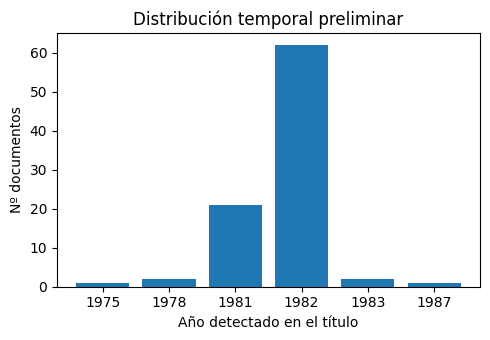

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_title_year_distribution.png

Conteo por año y sección:


,title_main_year,institutional_section_clean,n_documents
0,1975,interior,1
1,1978,interior,2
2,1981,defensa,9
3,1981,interior,12
4,1982,defensa,62
5,1983,interior,2
6,1987,defensa,1


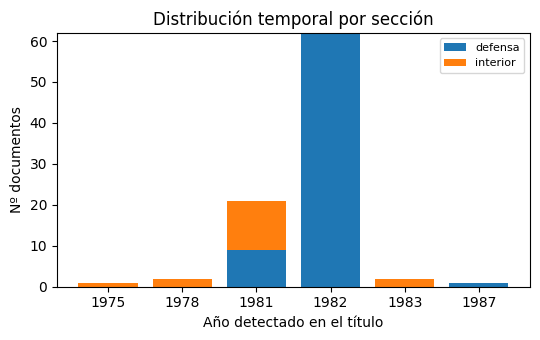

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_title_year_by_section.png


In [25]:
import matplotlib.pyplot as plt

print("=== VISUALIZACIÓN TEMPORAL DESDE TÍTULOS ===")

figures_dir = ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Filtrar documentos con año detectado en título
df_temporal_with_year = df_temporal[df_temporal["title_main_year"].notna()].copy()
df_temporal_with_year["title_main_year"] = df_temporal_with_year["title_main_year"].astype(int)

# Conteo por año
year_counts = (
    df_temporal_with_year["title_main_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(5, 3.5))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.xlabel("Año detectado en el título")
plt.ylabel("Nº documentos")
plt.title("Distribución temporal preliminar")
plt.tight_layout()

fig_path_1 = figures_dir / "eda_title_year_distribution.png"
plt.savefig(fig_path_1, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_1)

# Conteo por año y sección
year_section_counts = (
    df_temporal_with_year
    .groupby(["title_main_year", "institutional_section_clean"])
    .size()
    .reset_index(name="n_documents")
)

print("\nConteo por año y sección:")
display(year_section_counts)

# Gráfico apilado simple
pivot_year_section = year_section_counts.pivot(
    index="title_main_year",
    columns="institutional_section_clean",
    values="n_documents"
).fillna(0)

plt.figure(figsize=(5.5, 3.5))
bottom = None

for section in pivot_year_section.columns:
    values = pivot_year_section[section].values
    if bottom is None:
        plt.bar(pivot_year_section.index.astype(str), values, label=section)
        bottom = values
    else:
        plt.bar(pivot_year_section.index.astype(str), values, bottom=bottom, label=section)
        bottom = bottom + values

plt.xlabel("Año detectado en el título")
plt.ylabel("Nº documentos")
plt.title("Distribución temporal por sección")
plt.legend(fontsize=8)
plt.tight_layout()

fig_path_2 = figures_dir / "eda_title_year_by_section.png"
plt.savefig(fig_path_2, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path_2)

### Interpretación de la visualización temporal

La visualización temporal muestra la distribución de los documentos que contienen un año explícito en el título. Esta aclaración es importante, ya que 78 documentos del corpus no presentan un año directamente detectable en el título y, por tanto, no aparecen representados en estos gráficos.

Entre los documentos con año identificado, se observa una concentración clara en 1982. Este resultado es coherente con la presencia de numerosos documentos vinculados al desarrollo de la vista oral, el Consejo Supremo de Justicia Militar y la documentación judicial posterior al golpe. También aparecen documentos de 1981, asociados al año del intento de golpe de Estado y a sus consecuencias inmediatas, así como algunos antecedentes de 1975 y 1978, y documentos posteriores de 1983 y 1987.

El gráfico por sección institucional muestra que los documentos fechados en 1982 pertenecen principalmente a Defensa, mientras que Interior concentra documentos fechados en 1975, 1978, 1981 y 1983. Exteriores no aparece representado en esta visualización porque sus títulos suelen estar codificados mediante identificadores de expediente, como `D.31._AGA...` o `D.17._AGMAE...`, y no contienen años explícitos en el título.

Por tanto, este análisis debe interpretarse como una aproximación temporal preliminar basada únicamente en títulos. Para construir una línea temporal más completa sería necesario combinar información procedente del título, resumen, palabras clave y texto OCR, incorporando controles específicos para evitar errores derivados del reconocimiento automático de caracteres.

## 13. Análisis exploratorio de resúmenes y palabras clave

Además del texto OCR completo, el inventario de RTVE incluye dos campos de metadatos especialmente relevantes: `summary` y `keywords`. El campo `summary` contiene un resumen del contenido del documento, mientras que `keywords` recoge términos o fragmentos representativos asociados al documento.

Estos campos pueden ser útiles para tareas posteriores como búsqueda semántica, clasificación, generación de descripciones, recomendación de documentos o análisis temático. Sin embargo, antes de utilizarlos es necesario comprobar su cobertura, longitud, calidad básica y posibles limitaciones.

En este bloque se analiza cuántos documentos tienen resumen y palabras clave, qué longitud presentan estos campos y si existen documentos con metadatos vacíos o especialmente breves. Este análisis ayuda a decidir si estos campos pueden utilizarse como apoyo al texto completo o si deben tratarse únicamente como información auxiliar.

In [26]:
print("=== ANÁLISIS DE SUMMARY Y KEYWORDS ===")

df_meta = df_corpus_clean.copy()

# Asegurar formato string
df_meta["summary"] = df_meta["summary"].fillna("").astype(str)
df_meta["keywords"] = df_meta["keywords"].fillna("").astype(str)

# Métricas básicas
df_meta["has_summary"] = df_meta["summary"].str.strip() != ""
df_meta["has_keywords"] = df_meta["keywords"].str.strip() != ""

df_meta["summary_length_chars"] = df_meta["summary"].str.len()
df_meta["summary_length_words"] = df_meta["summary"].apply(lambda x: len(x.split()))

df_meta["keywords_length_chars"] = df_meta["keywords"].str.len()
df_meta["keywords_length_words"] = df_meta["keywords"].apply(lambda x: len(x.split()))

print("\nCobertura de summary y keywords:")
display(
    pd.DataFrame({
        "campo": ["summary", "keywords"],
        "documentos_con_valor": [
            df_meta["has_summary"].sum(),
            df_meta["has_keywords"].sum()
        ],
        "documentos_sin_valor": [
            (~df_meta["has_summary"]).sum(),
            (~df_meta["has_keywords"]).sum()
        ],
        "porcentaje_con_valor": [
            df_meta["has_summary"].mean() * 100,
            df_meta["has_keywords"].mean() * 100
        ]
    })
)

print("\nResumen de longitud de summaries:")
display(
    df_meta[["summary_length_chars", "summary_length_words"]]
    .describe()
    .T
)

print("\nResumen de longitud de keywords:")
display(
    df_meta[["keywords_length_chars", "keywords_length_words"]]
    .describe()
    .T
)

print("\nDocumentos con summaries más cortos:")
display(
    df_meta[
        ["doc_id", "title", "institutional_section_clean", "summary", "summary_length_words"]
    ]
    .sort_values("summary_length_words", ascending=True)
    .head(10)
)

print("\nDocumentos con summaries más largos:")
display(
    df_meta[
        ["doc_id", "title", "institutional_section_clean", "summary", "summary_length_words"]
    ]
    .sort_values("summary_length_words", ascending=False)
    .head(10)
)

print("\nEjemplos de keywords:")
display(
    df_meta[
        ["doc_id", "title", "institutional_section_clean", "keywords", "keywords_length_words"]
    ]
    .head(15)
)

# Guardar tabla de metadatos analizados
metadata_summary_path = tables_dir / "eda_metadata_summary_keywords_rtve.csv"
df_meta.to_csv(metadata_summary_path, index=False)

print("\nTabla guardada en:")
print(metadata_summary_path)

=== ANÁLISIS DE SUMMARY Y KEYWORDS ===

Cobertura de summary y keywords:


,campo,documentos_con_valor,documentos_sin_valor,porcentaje_con_valor
0,summary,167,0,100.0
1,keywords,167,0,100.0



Resumen de longitud de summaries:


,count,mean,std,min,25%,50%,75%,max
summary_length_chars,167.0,303.000000,0.000000,303.0,303.0,303.0,303.0,303.0
summary_length_words,167.0,48.568862,3.050734,39.0,47.0,49.0,51.0,56.0



Resumen de longitud de keywords:


...


Documentos con summaries más largos:


,doc_id,title,institutional_section_clean,summary,summary_length_words
99,rtve_1761,D.17._AGMAE_R40201_Exp._215,exteriores,La página 1 presenta una comunicación oficial ...,56
87,rtve_1773,D.28._AGA-83-09301_exp._5,exteriores,La página 1 contiene mensajes oficiales de apo...,55
90,rtve_1770,D.25._AGA-83-08764_exp._5,exteriores,El documento consta de dos páginas relacionada...,54
120,rtve_1740,RESERVADO: dación en cuenta de recurso de quej...,defensa,La página 1 contiene una providencia del Conse...,54
142,rtve_1718,RESERVADO: Hoja de servicios del Cap. Sánchez ...,defensa,La página 1 contiene un telegrama postal de la...,54
140,rtve_1720,SECRETO: oficio dando cuenta toma de declaración.,defensa,El documento es un comunicado oficial del Juzg...,54
7,rtve_1853,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,Resumen global del documento sobre el intento ...,53
45,rtve_1815,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,El documento detalla la sesión del 10 de mayo ...,53
64,rtve_1796,Informe sobre la participación de miembros de ...,defensa,El informe analiza la implicación de seis miem...,53
101,rtve_1759,D.15._AGMAE_R40201_Exp._215,exteriores,El documento consta de una comunicación oficia...,53



Ejemplos de keywords:


,doc_id,title,institutional_section_clean,keywords,keywords_length_words
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,5
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,9
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,9
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,9
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,7
5,rtve_1855,Información integrada (11 de marzo de 1982).,defensa,N/RFA:C/DI/ 4132 /11-3-82 Vista pública Causa ...,7
6,rtve_1854,Información integrada (16 de marzo de 1982).,defensa,C/DI/4339/16-03-82 DTOR. vista pública,4
7,rtve_1853,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3.464/02-03-82 D'OR Vista oral,4
8,rtve_1852,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3644/05-03-82 Vista oral Causa 2/81,5
9,rtve_1851,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3835/08-03-82 NOTA INFORMATIVA VISTA ORAL,5



Tabla guardada en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_metadata_summary_keywords_rtve.csv


### Diagnóstico de posible truncamiento en `summary` y naturaleza de `keywords`

Aunque los campos `summary` y `keywords` están disponibles para todos los documentos, el análisis de longitud muestra que todos los resúmenes tienen exactamente 303 caracteres. Este patrón sugiere que el campo podría estar truncado o limitado por la fuente o por el proceso de extracción.

Además, los ejemplos de `keywords` indican que este campo no contiene únicamente palabras clave semánticas, sino también códigos administrativos, referencias internas, fechas y fragmentos del encabezado documental. Por ello, se realiza una comprobación adicional para entender mejor la naturaleza de ambos campos antes de decidir su uso en fases posteriores.

In [27]:
print("=== DIAGNÓSTICO ADICIONAL DE SUMMARY Y KEYWORDS ===")

df_meta_check = df_meta.copy()

# Comprobar posibles señales de truncamiento
df_meta_check["summary_ends_with_dots"] = df_meta_check["summary"].str.strip().str.endswith("...")
df_meta_check["summary_ends_with_incomplete"] = df_meta_check["summary"].str.strip().str[-1].isin([",", ";", ":", "-", "—"])

print("\nSummaries que terminan con puntos suspensivos:")
print(df_meta_check["summary_ends_with_dots"].sum())

print("\nSummaries que terminan con signo potencialmente incompleto:")
print(df_meta_check["summary_ends_with_incomplete"].sum())

print("\nÚltimos 120 caracteres de algunos summaries:")
for _, row in df_meta_check.head(10).iterrows():
    print("\n" + "="*80)
    print("doc_id:", row["doc_id"])
    print("title:", row["title"])
    print("summary final:")
    print(row["summary"][-120:])

# Patrones simples en keywords
df_meta_check["keywords_has_date_pattern"] = df_meta_check["keywords"].str.contains(
    r"\d{1,2}[-/\.]\d{1,2}[-/\.]\d{2,4}|\d{2}[-/\.]\d{2}[-/\.]\d{2}",
    regex=True
)

df_meta_check["keywords_has_reference_code"] = df_meta_check["keywords"].str.contains(
    r"C/|SG|DI|Ref|N/Ref|AGMAE|AGA|Exp",
    regex=True,
    case=False
)

print("\nKeywords con patrón de fecha:")
print(df_meta_check["keywords_has_date_pattern"].sum())

print("\nKeywords con códigos/referencias administrativas:")
print(df_meta_check["keywords_has_reference_code"].sum())

print("\nEjemplos de keywords con códigos o referencias:")
display(
    df_meta_check[df_meta_check["keywords_has_reference_code"]][
        ["doc_id", "title", "institutional_section_clean", "keywords"]
    ]
    .head(20)
)

# Guardar diagnóstico actualizado
metadata_check_path = tables_dir / "eda_metadata_summary_keywords_check_rtve.csv"
df_meta_check.to_csv(metadata_check_path, index=False)

print("\nTabla guardada en:")
print(metadata_check_path)

=== DIAGNÓSTICO ADICIONAL DE SUMMARY Y KEYWORDS ===

Summaries que terminan con puntos suspensivos:
167

Summaries que terminan con signo potencialmente incompleto:
0

Últimos 120 caracteres de algunos summaries:

doc_id: rtve_1860
title: Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).
summary final:
ones oficiales, aunque plagado de controversias por la interpretación y selección de testimonios, especialmente en re...

doc_id: rtve_1859
title: Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).
summary final:
izaron declaraciones y diligencias relacionadas con hechos militares y posibles conspiraciones. A lo largo de las ses...

doc_id: rtve_1858
title: Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).
summary final:
olémicas en torno a la cobertura mediática del Diario 16 y la actitud de los procesados, defensores y fuerzas militar...

doc_id: rtve_1857
title: Vista oral 2/81 del Consejo Supr

,doc_id,title,institutional_section_clean,keywords
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/2820/20-02-82 DTOR. Vista oral 2/81
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...
5,rtve_1855,Información integrada (11 de marzo de 1982).,defensa,N/RFA:C/DI/ 4132 /11-3-82 Vista pública Causa ...
6,rtve_1854,Información integrada (16 de marzo de 1982).,defensa,C/DI/4339/16-03-82 DTOR. vista pública
7,rtve_1853,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3.464/02-03-82 D'OR Vista oral
8,rtve_1852,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3644/05-03-82 Vista oral Causa 2/81
9,rtve_1851,Vista oral 2/81 del Consejo Supremo de Justici...,defensa,C/SG/3835/08-03-82 NOTA INFORMATIVA VISTA ORAL



Tabla guardada en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/eda_metadata_summary_keywords_check_rtve.csv


### Interpretación del análisis de `summary` y `keywords`

El análisis de los campos `summary` y `keywords` muestra que ambos están presentes en los 167 documentos del corpus. Sin embargo, su naturaleza y utilidad son distintas a las del texto OCR completo.

En el caso de `summary`, todos los documentos presentan un resumen, pero todos ellos tienen exactamente 303 caracteres y terminan con puntos suspensivos. Esto indica que el campo está truncado o limitado a una longitud fija por la fuente o por el proceso de extracción. Por tanto, aunque puede utilizarse como vista previa o descripción breve del documento, no debe interpretarse como un resumen completo del contenido.

El campo `keywords` también está completo para todos los documentos, pero su inspección muestra que no contiene únicamente palabras clave semánticas. En muchos casos incluye códigos administrativos, referencias internas, fechas, identificadores documentales o fragmentos del encabezado del documento. De hecho, se detectan patrones de fecha en 58 documentos y códigos o referencias administrativas en 79 documentos.

A partir de este diagnóstico, se decide que el campo principal para análisis textual y modelado será `text_full`, ya que contiene el texto OCR completo. El campo `summary` podrá emplearse como apoyo descriptivo o vista previa, mientras que `keywords` podrá ser útil para identificar referencias documentales, fechas o códigos internos, pero no como una lista limpia de temas sin un tratamiento previo.

Esta revisión evita asumir erróneamente que los metadatos disponibles son directamente equivalentes al contenido textual completo o a etiquetas temáticas validadas.

## 14. Cierre del EDA y preparación del dataset base

Tras completar el análisis exploratorio, se consolida una versión base del corpus que recoge las variables principales del inventario, el texto OCR completo, la clasificación institucional limpia, las métricas de calidad textual, los indicadores de revisión, la información temporal preliminar y el diagnóstico de metadatos.

Este dataset no representa todavía el conjunto final de entrenamiento para modelos, sino una versión preparada para continuar el proyecto en notebooks posteriores. A partir de esta tabla se podrán desarrollar tareas como clasificación supervisada, clustering, análisis temático, extracción de entidades, grafos de relaciones o búsqueda semántica.

La creación de este dataset permite separar claramente la fase de EDA de las fases posteriores de modelado. Además, deja documentadas las decisiones tomadas hasta este punto y evita repetir cálculos exploratorios en otros notebooks.

In [28]:
print("=== CREACIÓN DEL DATASET BASE TRAS EDA ===")

# Partimos del corpus institucional limpio
df_eda_ready = df_corpus_clean.copy()

# ------------------------------------------------------------
# 1. Añadir flags de calidad OCR/documental
# ------------------------------------------------------------

quality_flag_cols = [
    "doc_id",
    "alpha_ratio",
    "digit_ratio",
    "space_ratio",
    "uppercase_ratio",
    "empty_line_ratio",
    "avg_line_length",
    "weird_char_ratio",
    "flag_low_alpha_ratio",
    "flag_high_weird_chars",
    "flag_high_uppercase",
    "flag_short_text",
    "flag_long_text_outlier",
    "n_quality_flags"
]

df_eda_ready = df_eda_ready.merge(
    df_quality_flags[quality_flag_cols],
    on="doc_id",
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 2. Añadir variables temporales preliminares
# ------------------------------------------------------------

temporal_cols = [
    "doc_id",
    "title_years",
    "n_title_years",
    "title_main_year"
]

df_eda_ready = df_eda_ready.merge(
    df_temporal[temporal_cols],
    on="doc_id",
    how="left",
    validate="one_to_one"
)

# Convertimos la lista de años a texto para guardar bien en CSV
df_eda_ready["title_years"] = df_eda_ready["title_years"].apply(
    lambda x: ", ".join(map(str, x)) if isinstance(x, list) else ""
)

# ------------------------------------------------------------
# 3. Añadir diagnóstico de summary y keywords
# ------------------------------------------------------------

metadata_cols = [
    "doc_id",
    "has_summary",
    "has_keywords",
    "summary_length_chars",
    "summary_length_words",
    "keywords_length_chars",
    "keywords_length_words",
    "summary_ends_with_dots",
    "summary_ends_with_incomplete",
    "keywords_has_date_pattern",
    "keywords_has_reference_code"
]

df_eda_ready = df_eda_ready.merge(
    df_meta_check[metadata_cols],
    on="doc_id",
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 4. Ordenar columnas principales para que el dataset sea legible
# ------------------------------------------------------------

main_cols = [
    "doc_id",
    "source",
    "source_document_id",
    "title",
    "institutional_section_clean",
    "institutional_subsection_clean",
    "institutional_group_clean",
    "institutional_label_source",
    "coverage_type",
    "pages",
    "text_length_chars",
    "text_length_words",
    "title_main_year",
    "title_years",
    "n_title_years",
    "summary",
    "summary_length_words",
    "summary_ends_with_dots",
    "keywords",
    "keywords_length_words",
    "keywords_has_date_pattern",
    "keywords_has_reference_code",
    "text_extraction_ok",
    "extraction_source",
    "alpha_ratio",
    "digit_ratio",
    "uppercase_ratio",
    "weird_char_ratio",
    "n_quality_flags",
    "flag_low_alpha_ratio",
    "flag_high_weird_chars",
    "flag_high_uppercase",
    "flag_short_text",
    "flag_long_text_outlier",
    "detail_url",
    "pdf_url",
    "text_full"
]

# Mantener solo columnas que existan, por seguridad
main_cols_existing = [col for col in main_cols if col in df_eda_ready.columns]
df_eda_ready = df_eda_ready[main_cols_existing]

# ------------------------------------------------------------
# 5. Validaciones finales
# ------------------------------------------------------------

print("\nDimensiones del dataset preparado:")
print(df_eda_ready.shape)

print("\nDuplicados por doc_id:")
print(df_eda_ready["doc_id"].duplicated().sum())

print("\nDocumentos sin texto:")
print((df_eda_ready["text_full"].fillna("").str.strip() == "").sum())

print("\nDistribución institucional final:")
display(
    df_eda_ready["institutional_section_clean"]
    .value_counts()
    .to_frame("n_documentos")
)

print("\nOrigen de etiquetas institucionales:")
display(
    df_eda_ready["institutional_label_source"]
    .value_counts()
    .to_frame("n_documentos")
)

print("\nResumen de flags de calidad:")
display(
    df_eda_ready[
        [
            "flag_low_alpha_ratio",
            "flag_high_weird_chars",
            "flag_high_uppercase",
            "flag_short_text",
            "flag_long_text_outlier"
        ]
    ]
    .sum()
    .to_frame("n_documentos")
)

print("\nCobertura temporal desde títulos:")
display(
    df_eda_ready["title_main_year"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("n_documentos")
)

# ------------------------------------------------------------
# 6. Guardar dataset preparado
# ------------------------------------------------------------

processed_dir = ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

outputs_tables_dir = ROOT / "outputs" / "tables"
outputs_tables_dir.mkdir(parents=True, exist_ok=True)

processed_path = processed_dir / "rtve_corpus_eda_ready.csv"
output_path = outputs_tables_dir / "rtve_corpus_eda_ready.csv"

df_eda_ready.to_csv(processed_path, index=False)
df_eda_ready.to_csv(output_path, index=False)

print("\nDataset base guardado en:")
print(processed_path)
print(output_path)

=== CREACIÓN DEL DATASET BASE TRAS EDA ===

Dimensiones del dataset preparado:
(167, 37)

Duplicados por doc_id:
0

Documentos sin texto:
0

Distribución institucional final:


,n_documentos
institutional_section_clean,
defensa,108
exteriores,31
interior,28



Origen de etiquetas institucionales:


,n_documentos
institutional_label_source,
moncloa_match,155
inferred_from_rtve_title,12



Resumen de flags de calidad:


,n_documentos
flag_low_alpha_ratio,4
flag_high_weird_chars,8
flag_high_uppercase,11
flag_short_text,26
flag_long_text_outlier,14



Cobertura temporal desde títulos:


,n_documentos
title_main_year,
1975.0,1
1978.0,2
1981.0,21
1982.0,62
1983.0,2
1987.0,1
NaN,78



Dataset base guardado en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/data/processed/rtve_corpus_eda_ready.csv
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/rtve_corpus_eda_ready.csv


## 15. Conclusiones principales del EDA

El análisis exploratorio realizado permite concluir que el corpus principal del proyecto está formado por 167 documentos procedentes de RTVE, todos ellos con texto OCR disponible. La fuente RTVE se considera la base principal del corpus, mientras que La Moncloa se utiliza como fuente institucional de contraste para enriquecer los documentos con información de sección y subsección.

La validación inicial muestra que no existen duplicados por `doc_id` y que todos los documentos del inventario tienen texto asociado. No obstante, el corpus presenta una elevada heterogeneidad en longitud documental. Existen documentos muy breves, de menos de 150 palabras, y documentos extremadamente extensos, como transcripciones o recopilaciones de más de 90.000 palabras. Por ello, en fases posteriores será necesario controlar el efecto de la longitud documental, especialmente en modelos basados en frecuencias, embeddings o clustering.

El diagnóstico de calidad OCR indica que el texto es utilizable para análisis NLP, aunque no está completamente libre de ruido. Se han detectado documentos con caracteres especiales, alta proporción de mayúsculas, textos muy cortos y textos muy largos. Estos casos se han marcado mediante indicadores de revisión, pero no se eliminan automáticamente del corpus.

La clasificación institucional limpia permite organizar el corpus en tres grandes bloques: Defensa, Interior y Exteriores. Defensa es la sección con mayor número de documentos, Interior concentra algunos de los textos más extensos y Exteriores contiene documentos generalmente más breves, con presencia de contenido diplomático y multilingüe. Además, se ha registrado la trazabilidad de las etiquetas institucionales para distinguir entre etiquetas procedentes del emparejamiento con La Moncloa y etiquetas inferidas desde títulos RTVE.

El análisis léxico, los n-gramas y el TF-IDF exploratorio muestran que las secciones institucionales presentan diferencias textuales interpretables. Defensa está asociada a vocabulario militar y judicial; Interior a Guardia Civil, Policía, comunicaciones y actores del golpe; y Exteriores a términos diplomáticos, internacionales y multilingües. Estos resultados justifican el interés de desarrollar modelos de clasificación, clustering temático y búsqueda semántica en fases posteriores.

El análisis temporal desde títulos permite identificar años explícitos en parte del corpus, con una concentración clara en 1982 y 1981. Sin embargo, esta aproximación es limitada, ya que muchos documentos no contienen años en el título, especialmente los documentos de Exteriores identificados mediante códigos de expediente. Por tanto, cualquier análisis temporal avanzado deberá combinar título, resumen, palabras clave y texto OCR con controles de calidad específicos.

Finalmente, el análisis de `summary` y `keywords` muestra que ambos campos están completos para todos los documentos, pero deben utilizarse con cautela. Los summaries están truncados a una longitud fija y terminan todos con puntos suspensivos, por lo que no deben interpretarse como resúmenes completos. Las keywords contienen con frecuencia códigos administrativos, fechas y referencias internas, por lo que no equivalen directamente a etiquetas temáticas limpias.

A partir de este EDA, se decide que el campo principal para análisis textual y modelado será `text_full`, complementado con variables institucionales limpias y metadatos auxiliares. Las transformaciones de texto para modelos supervisados deberán realizarse posteriormente dentro de pipelines ajustados únicamente sobre el conjunto de entrenamiento para evitar data leakage.